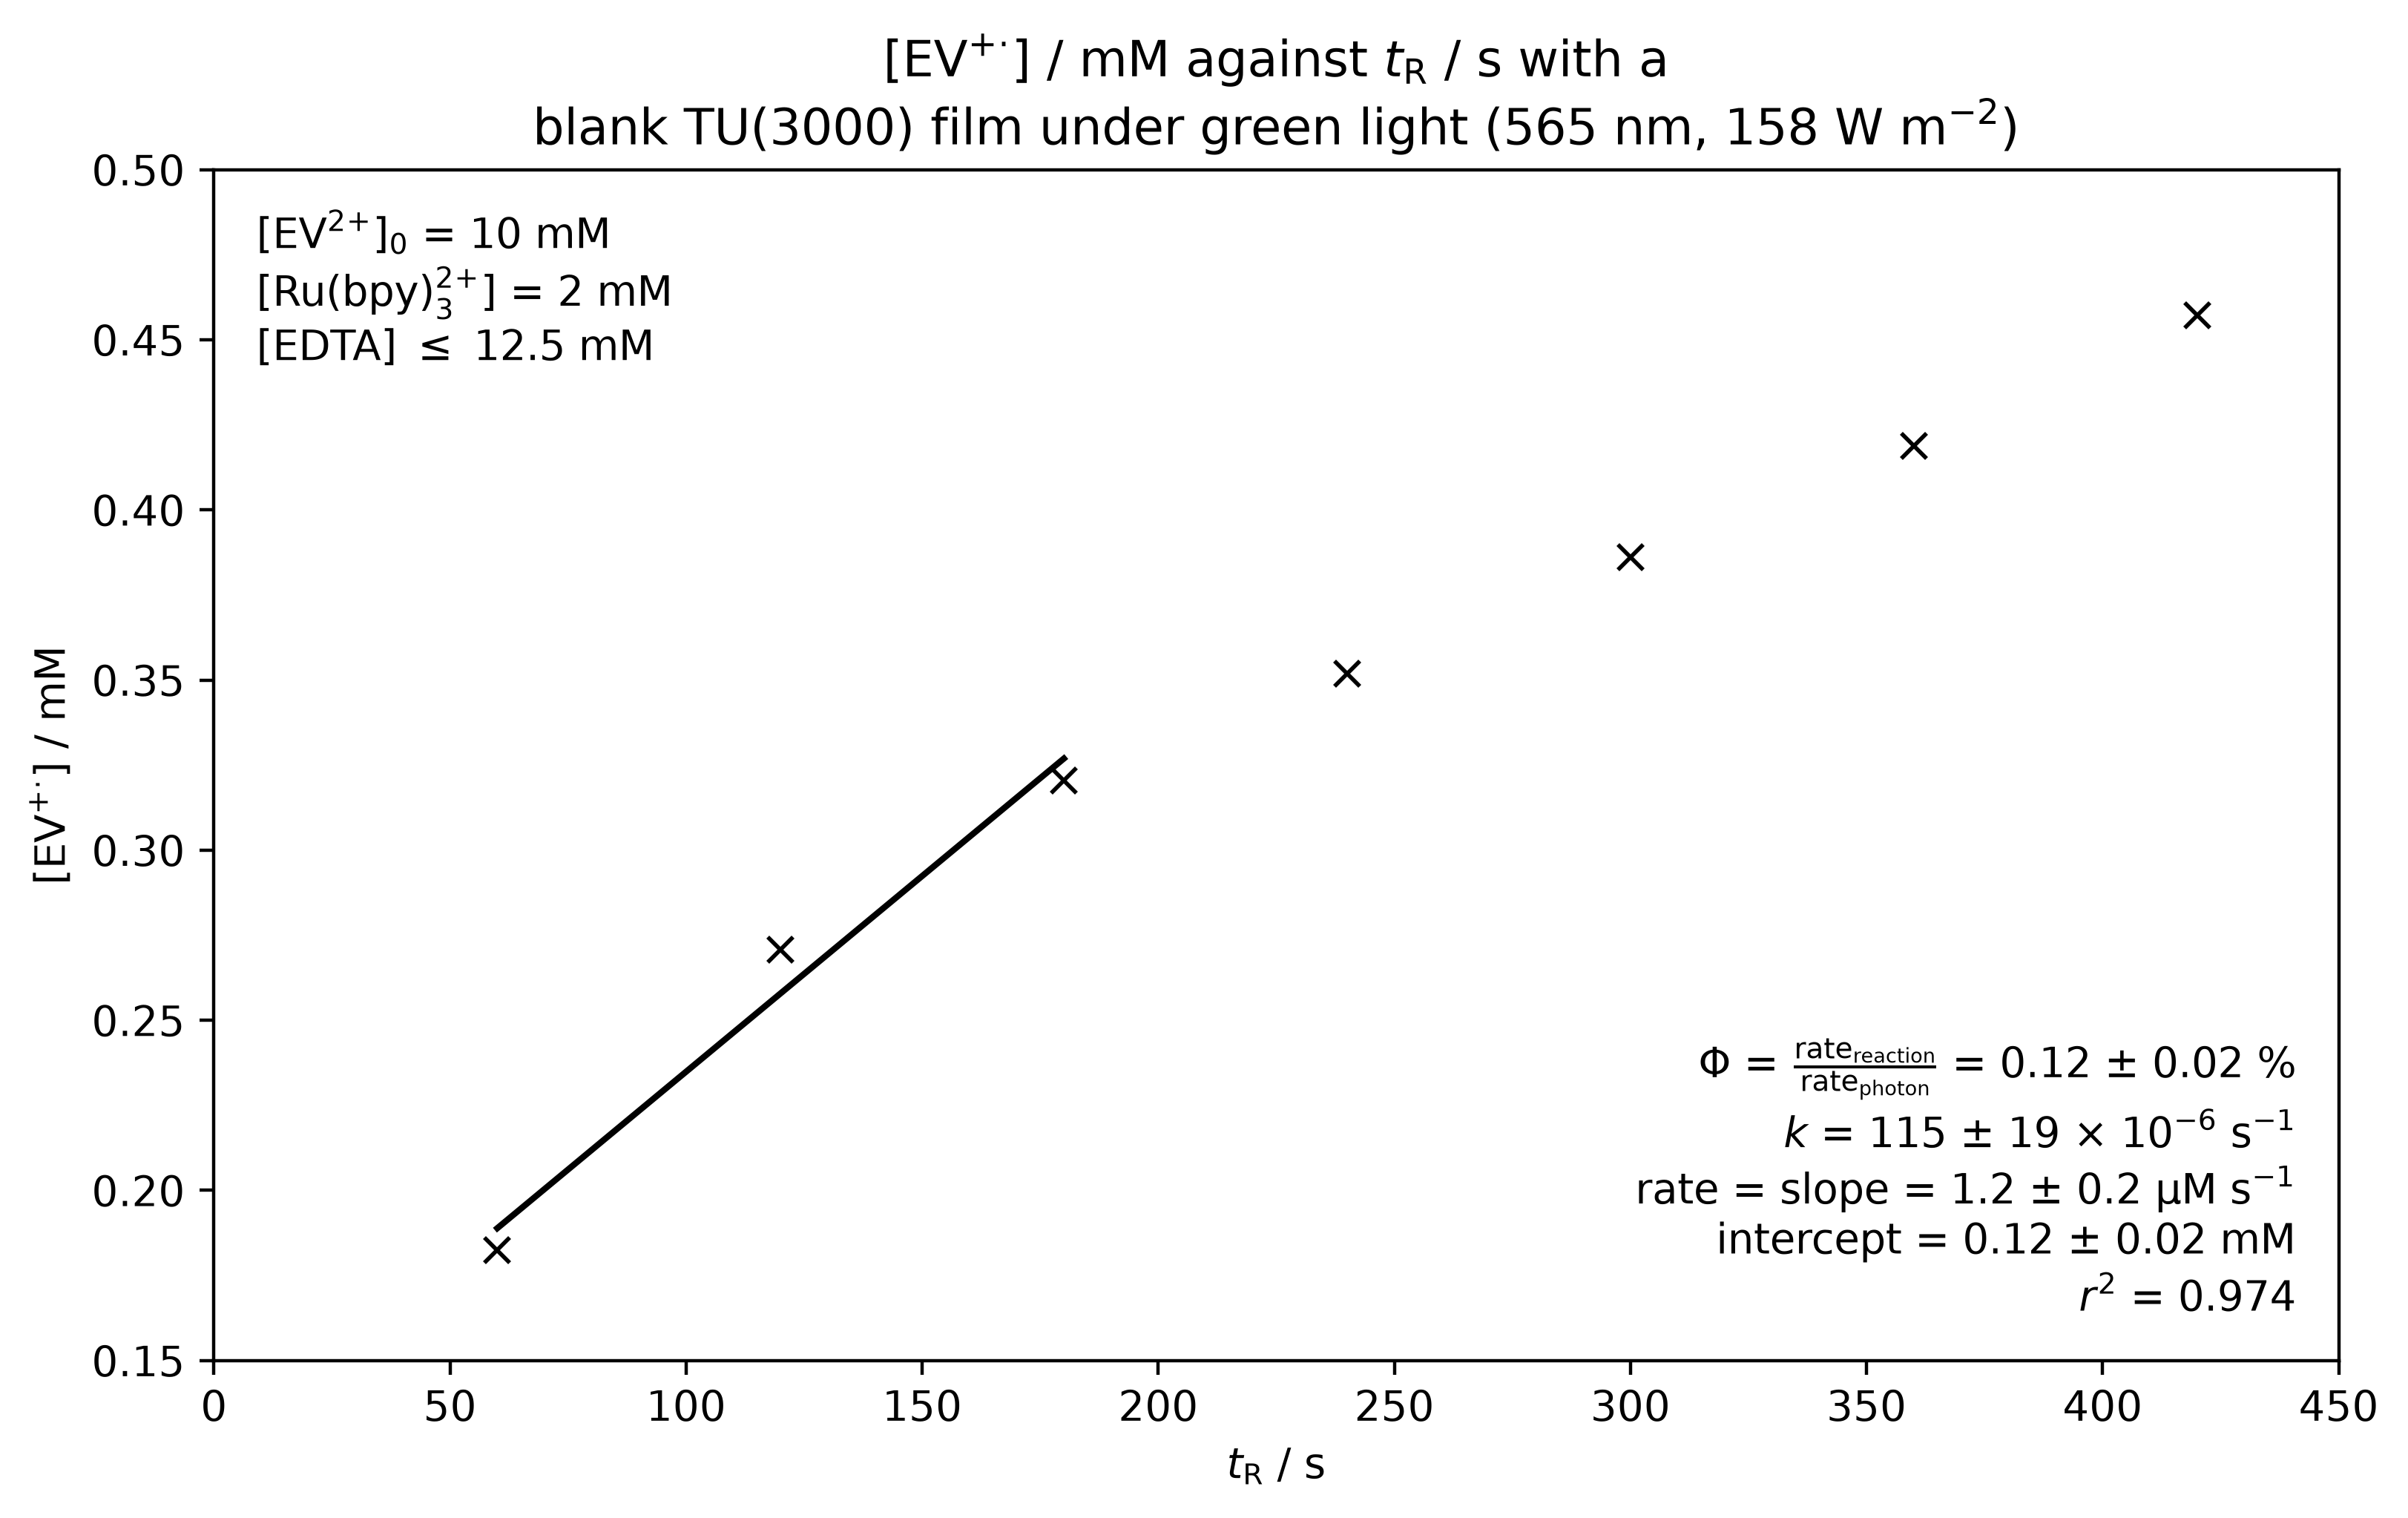

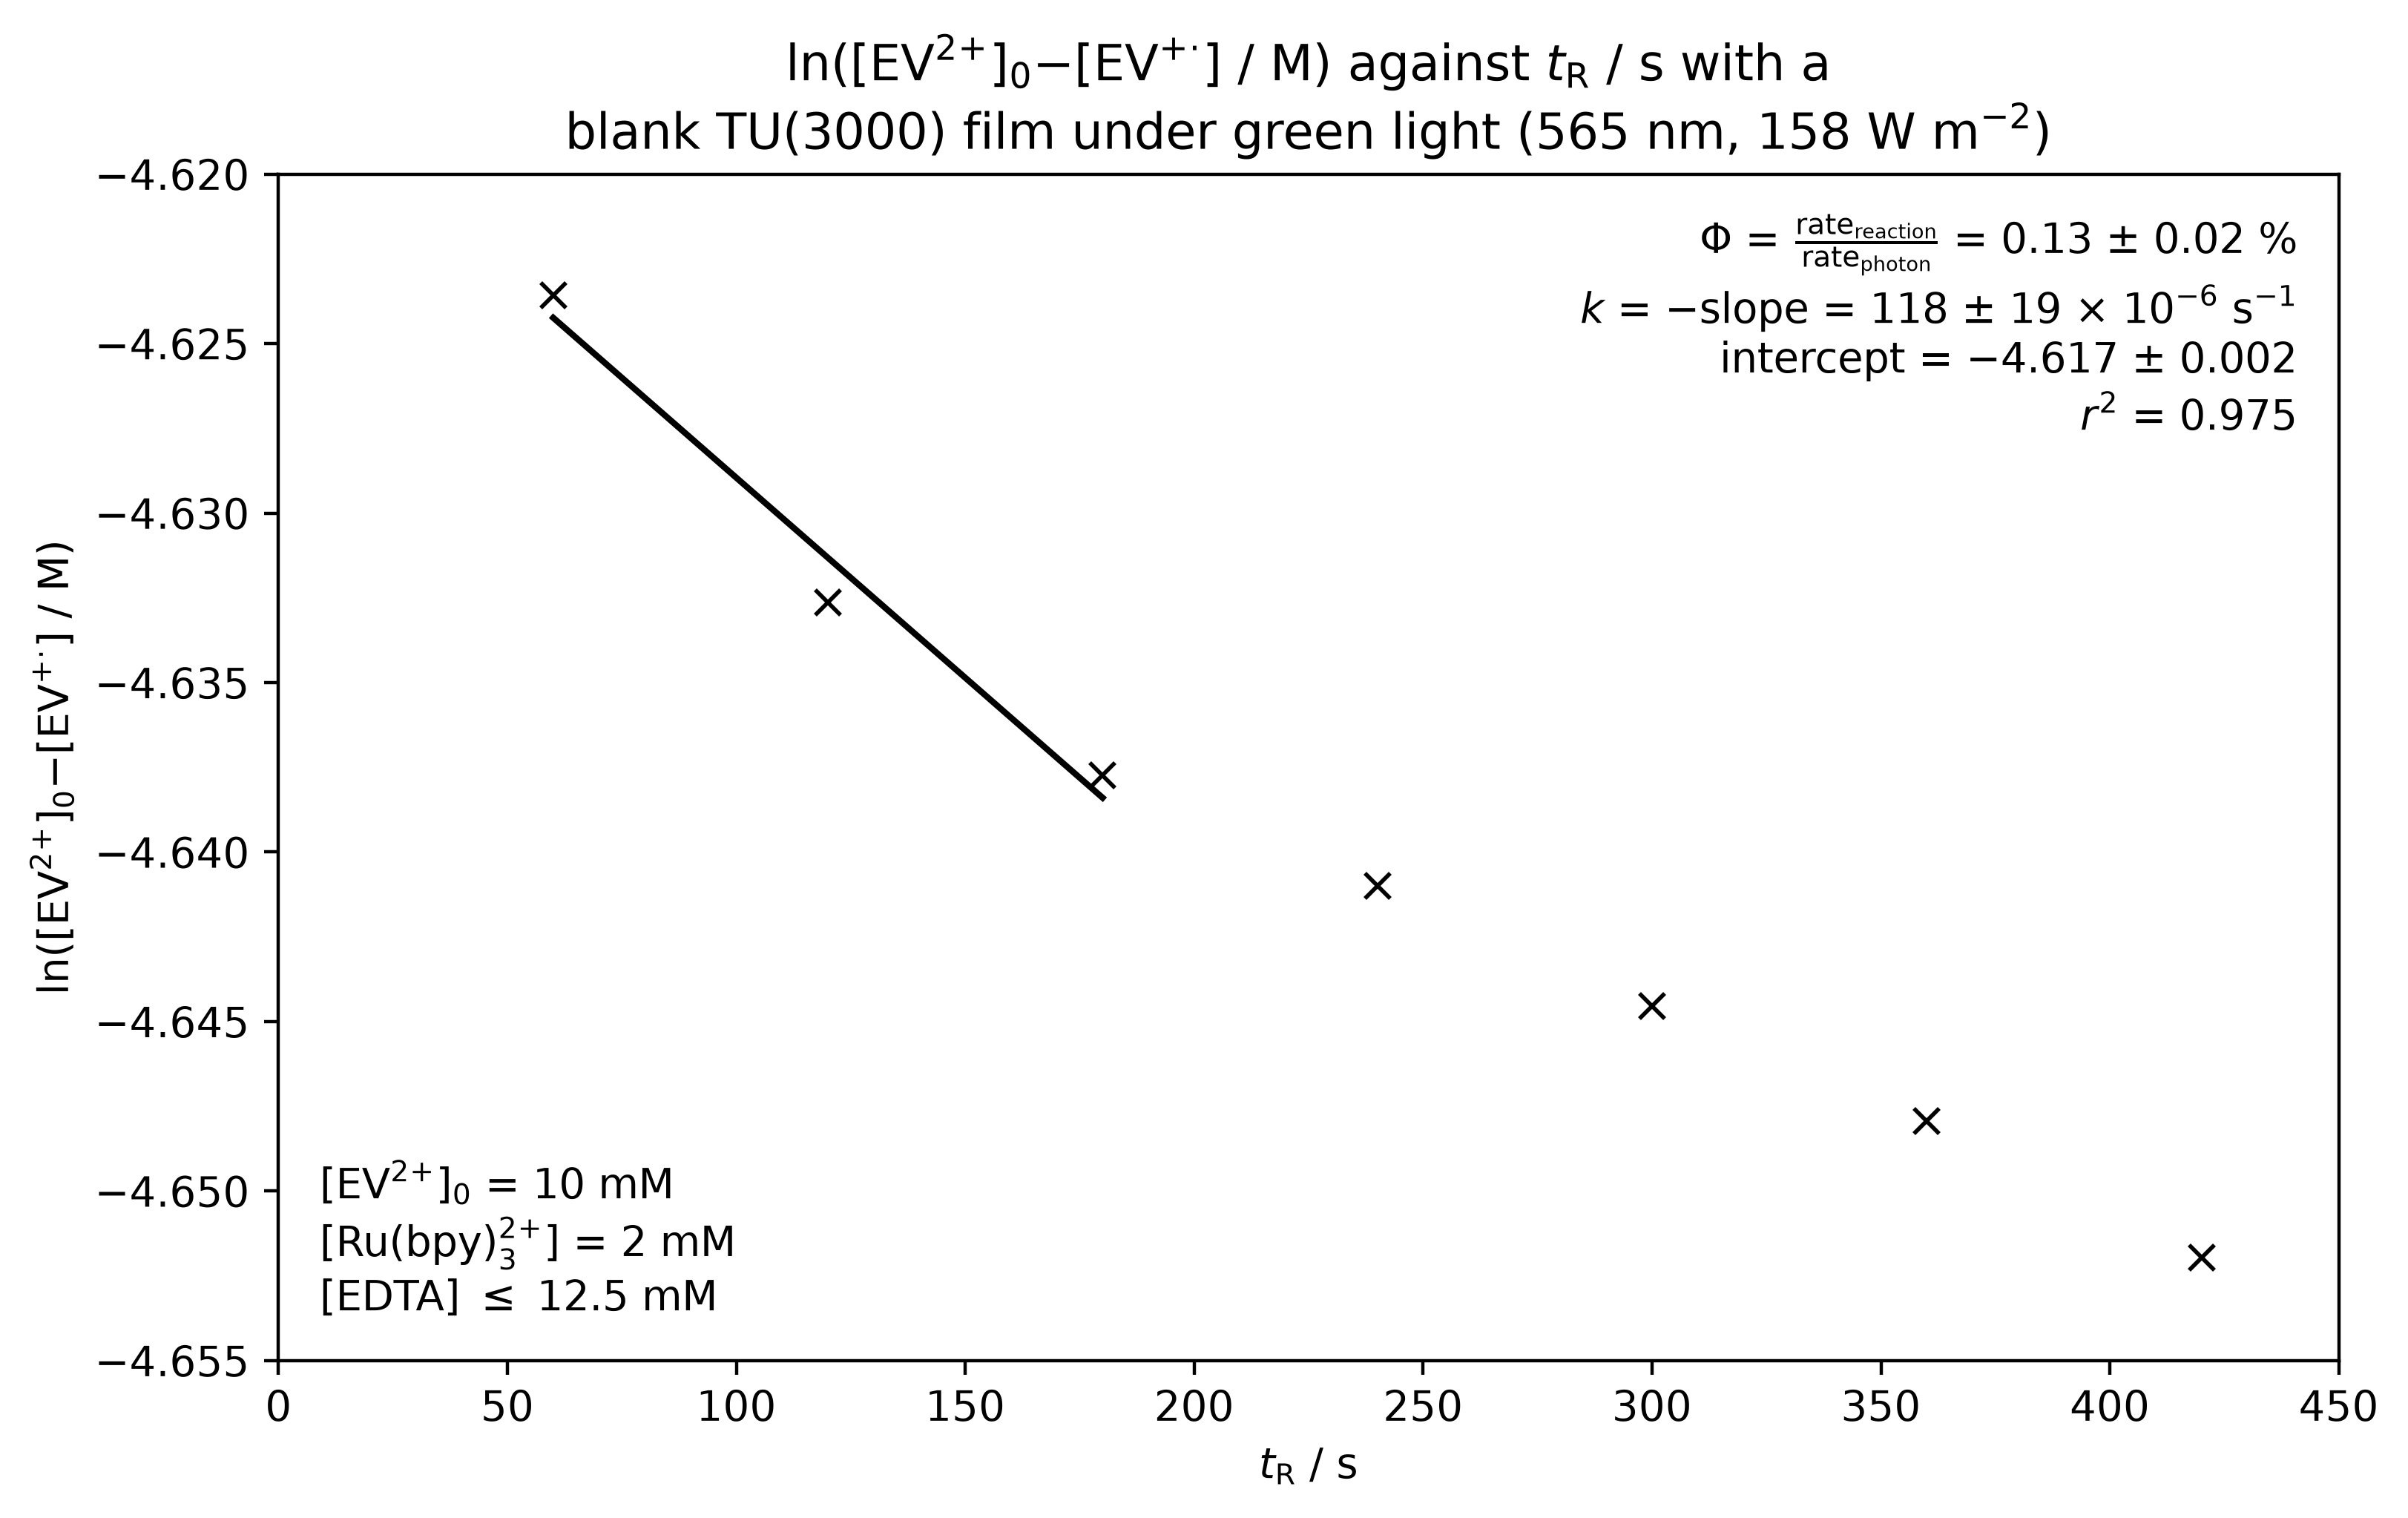

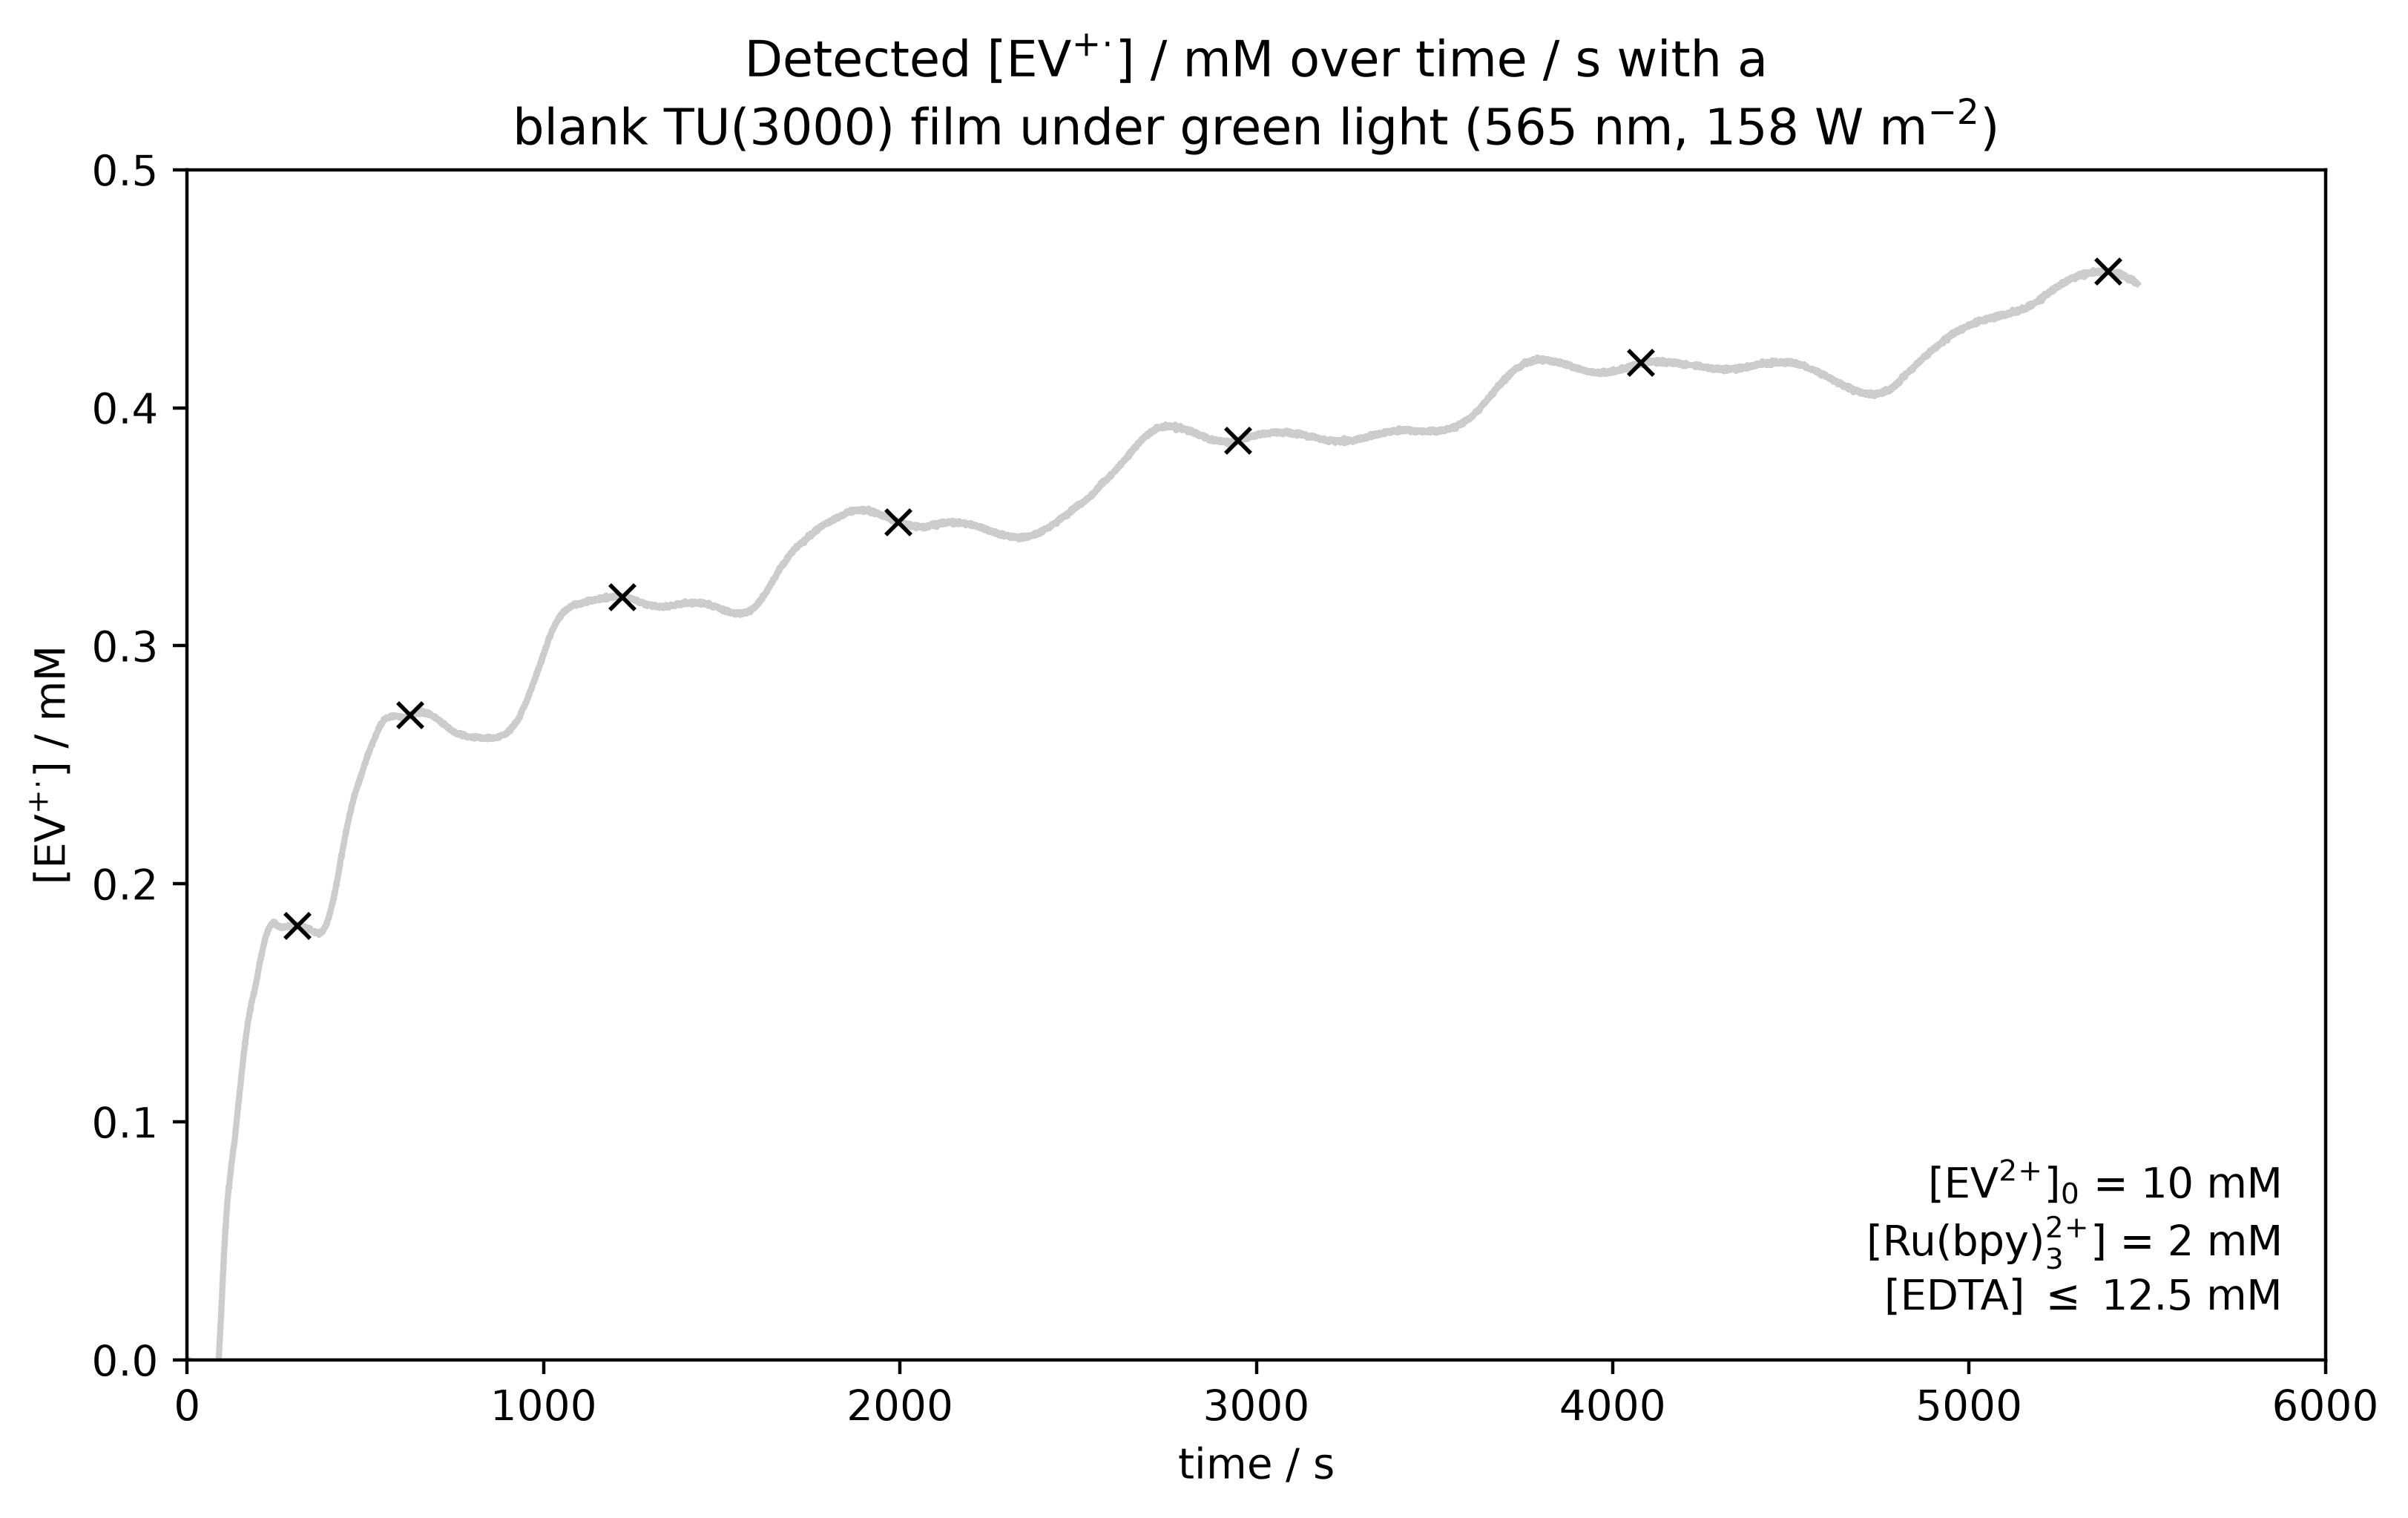

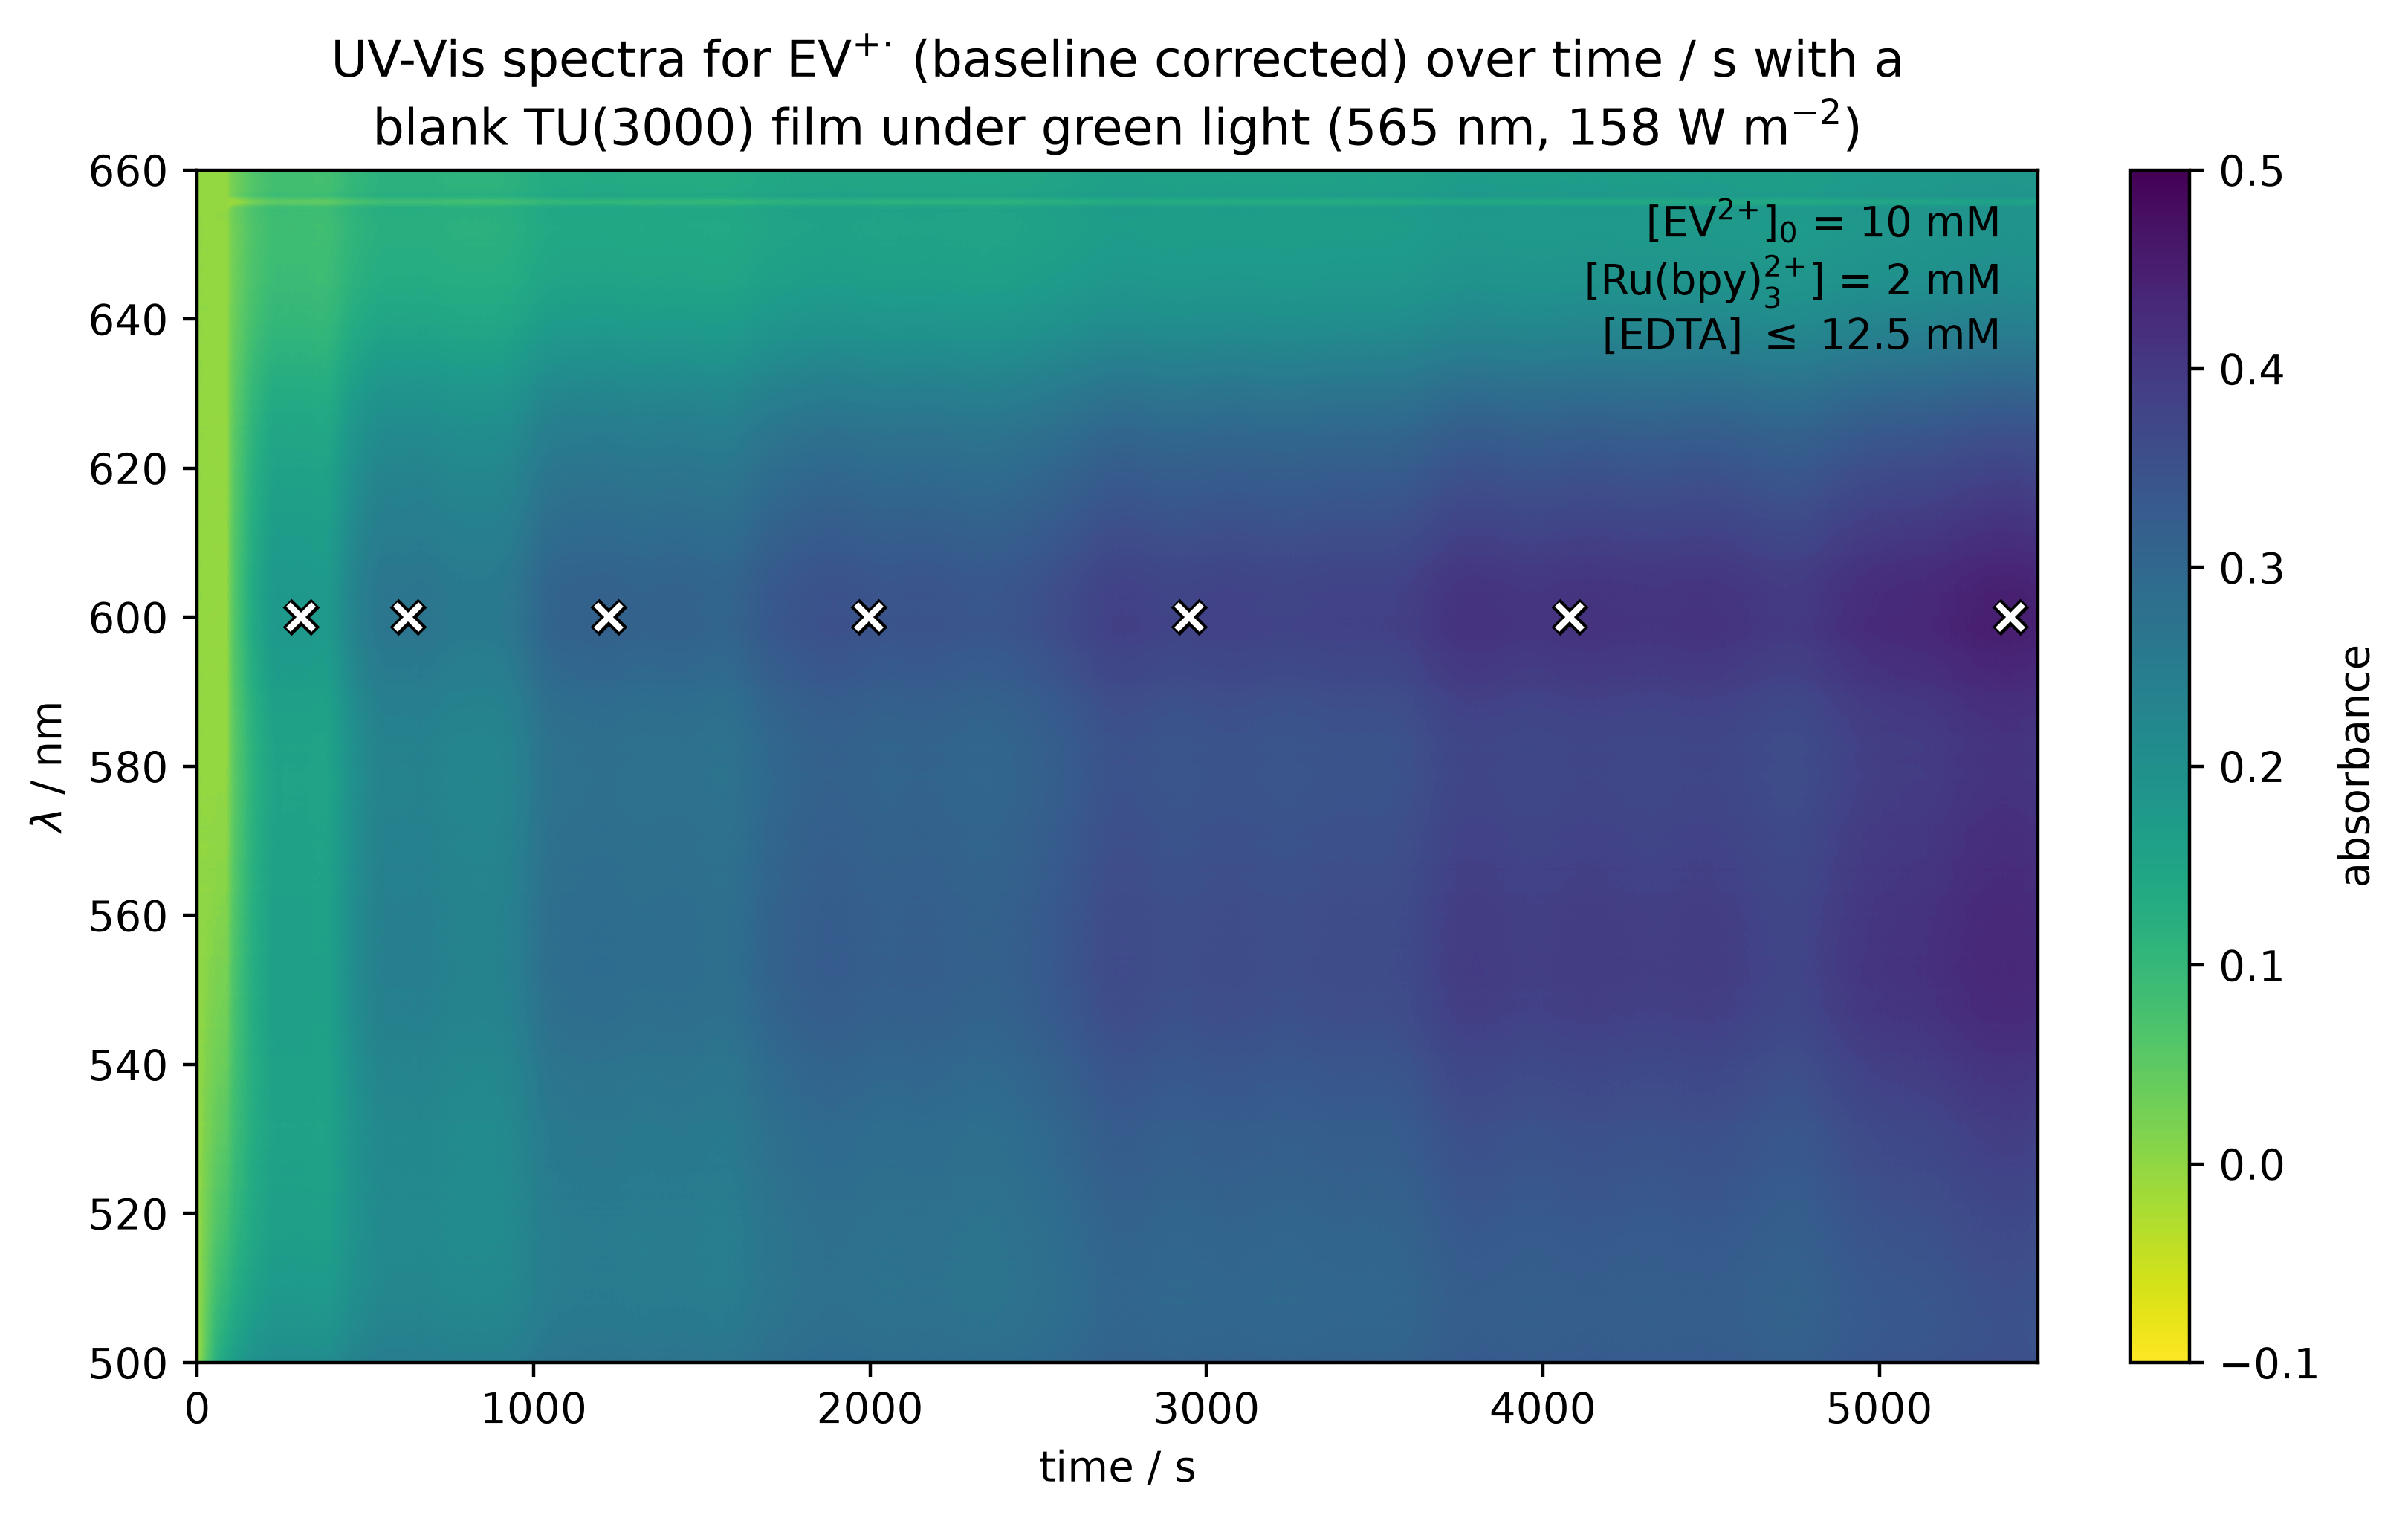

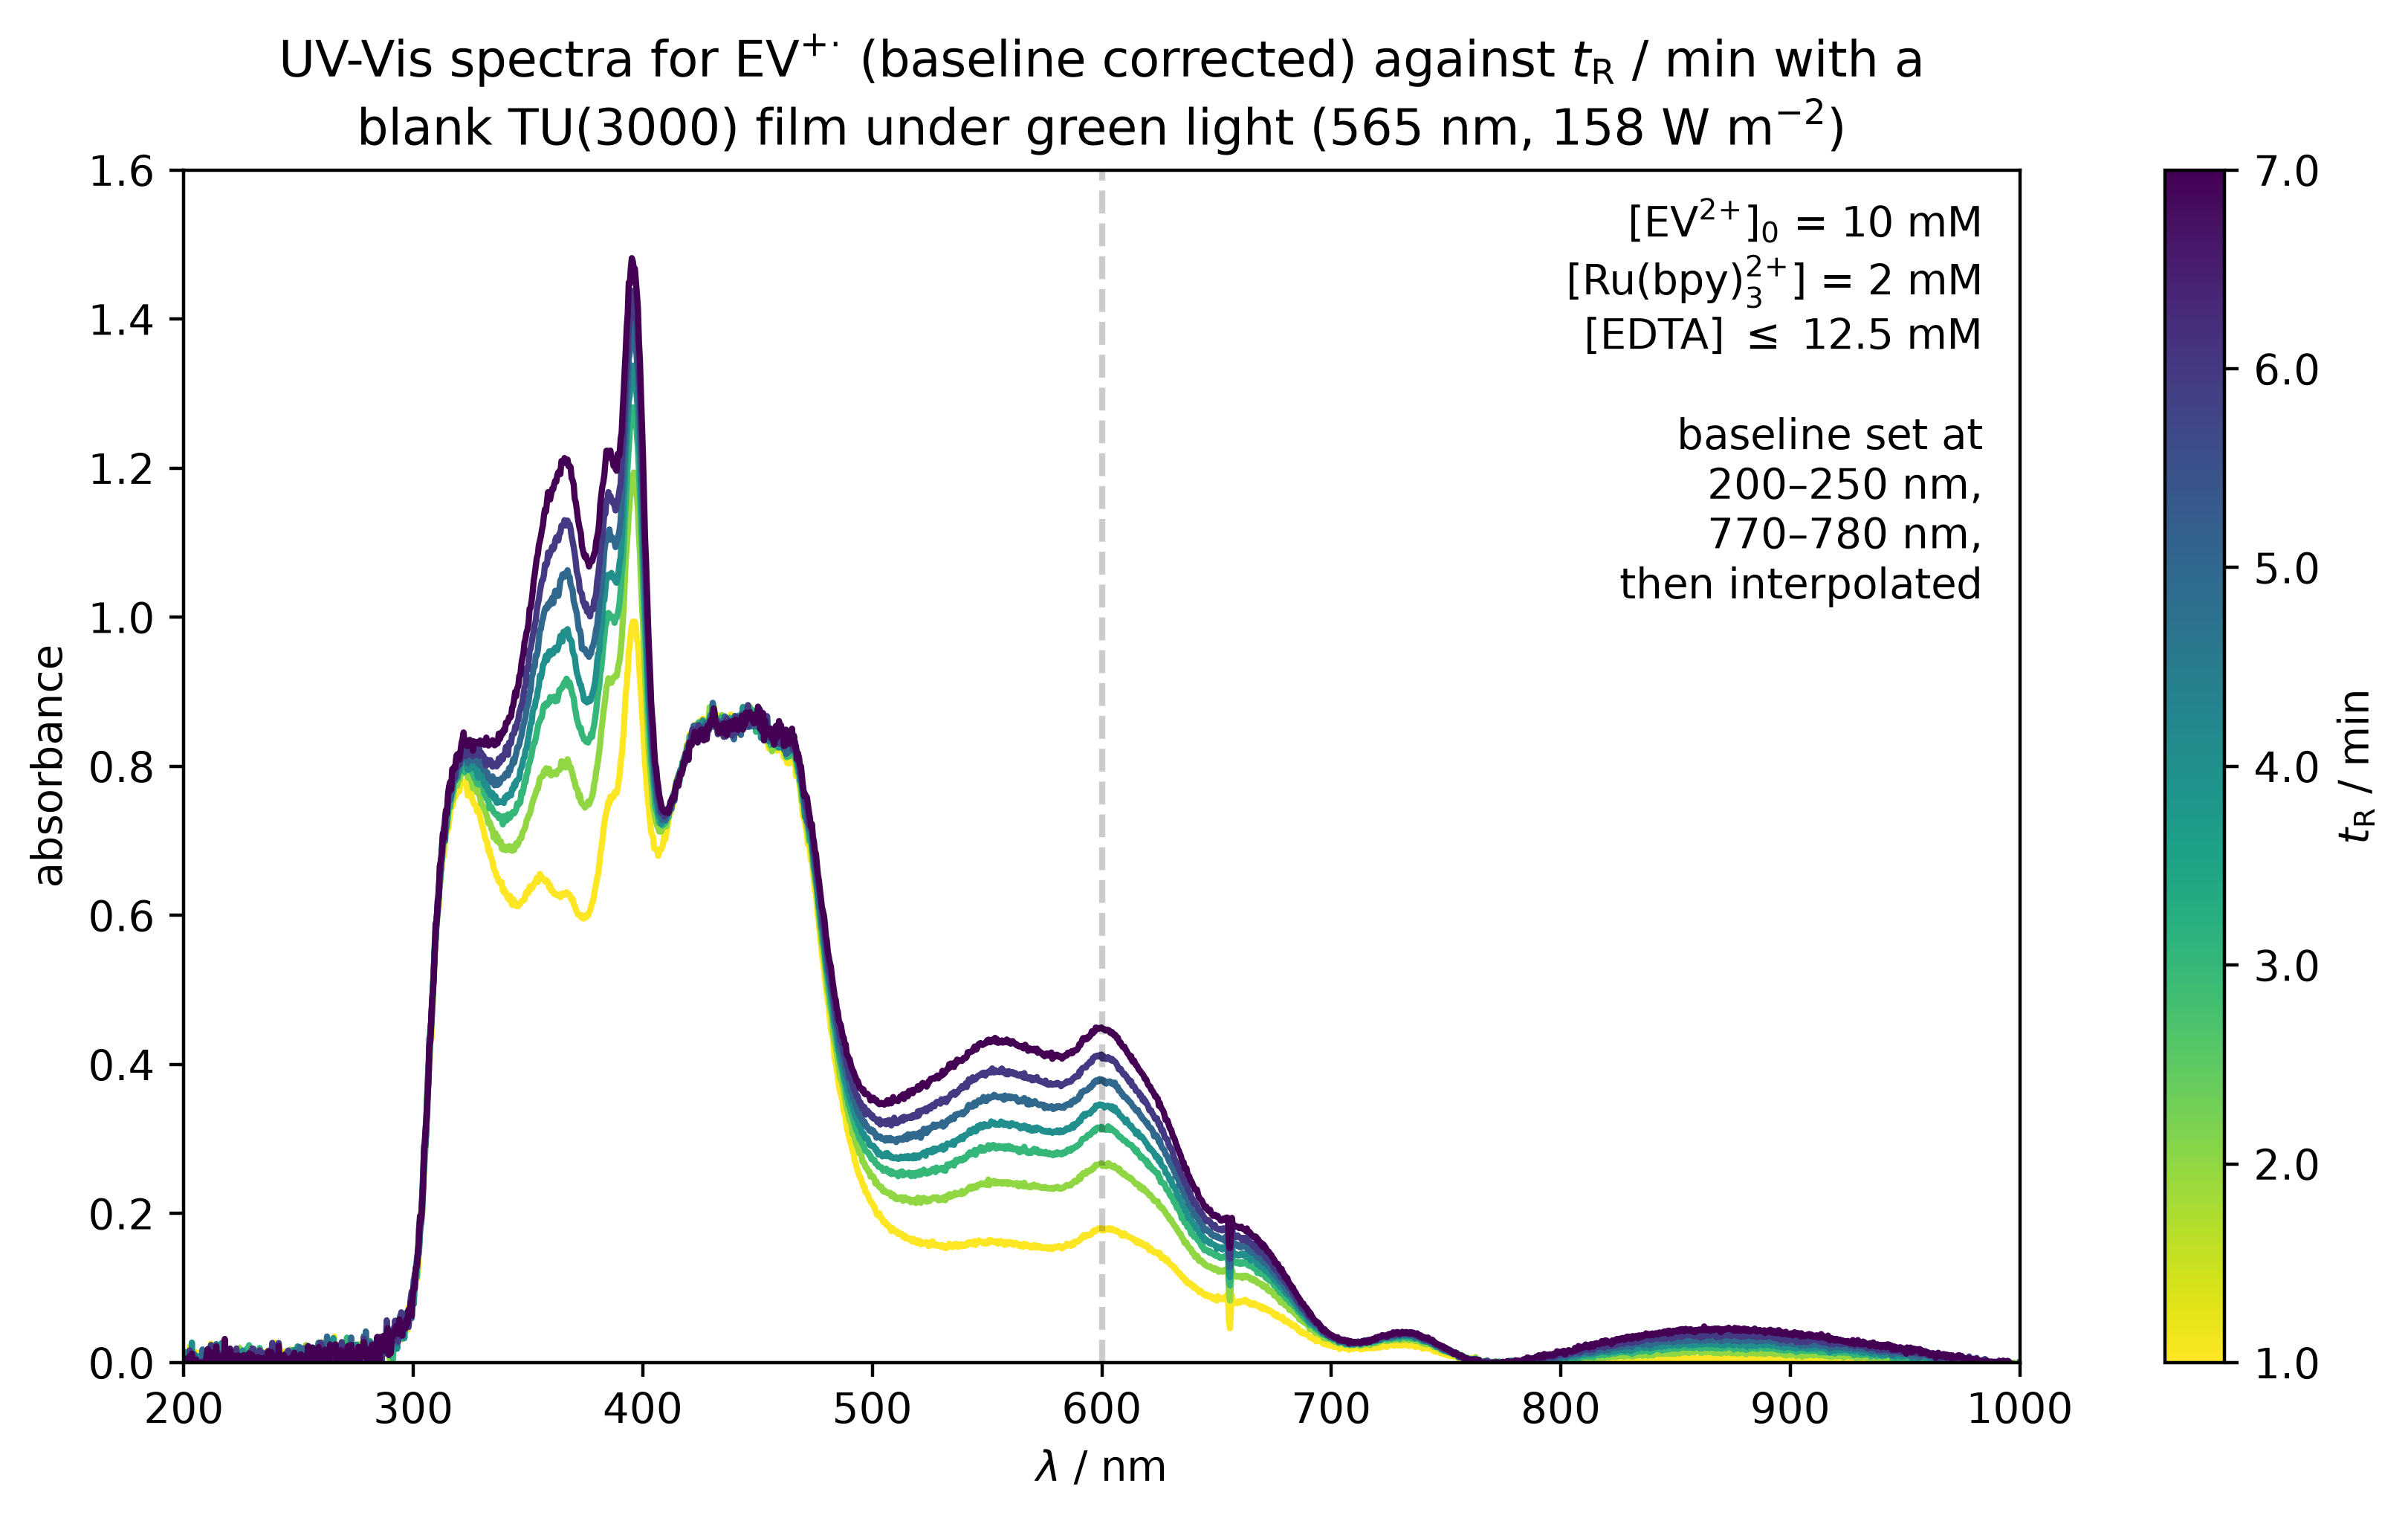

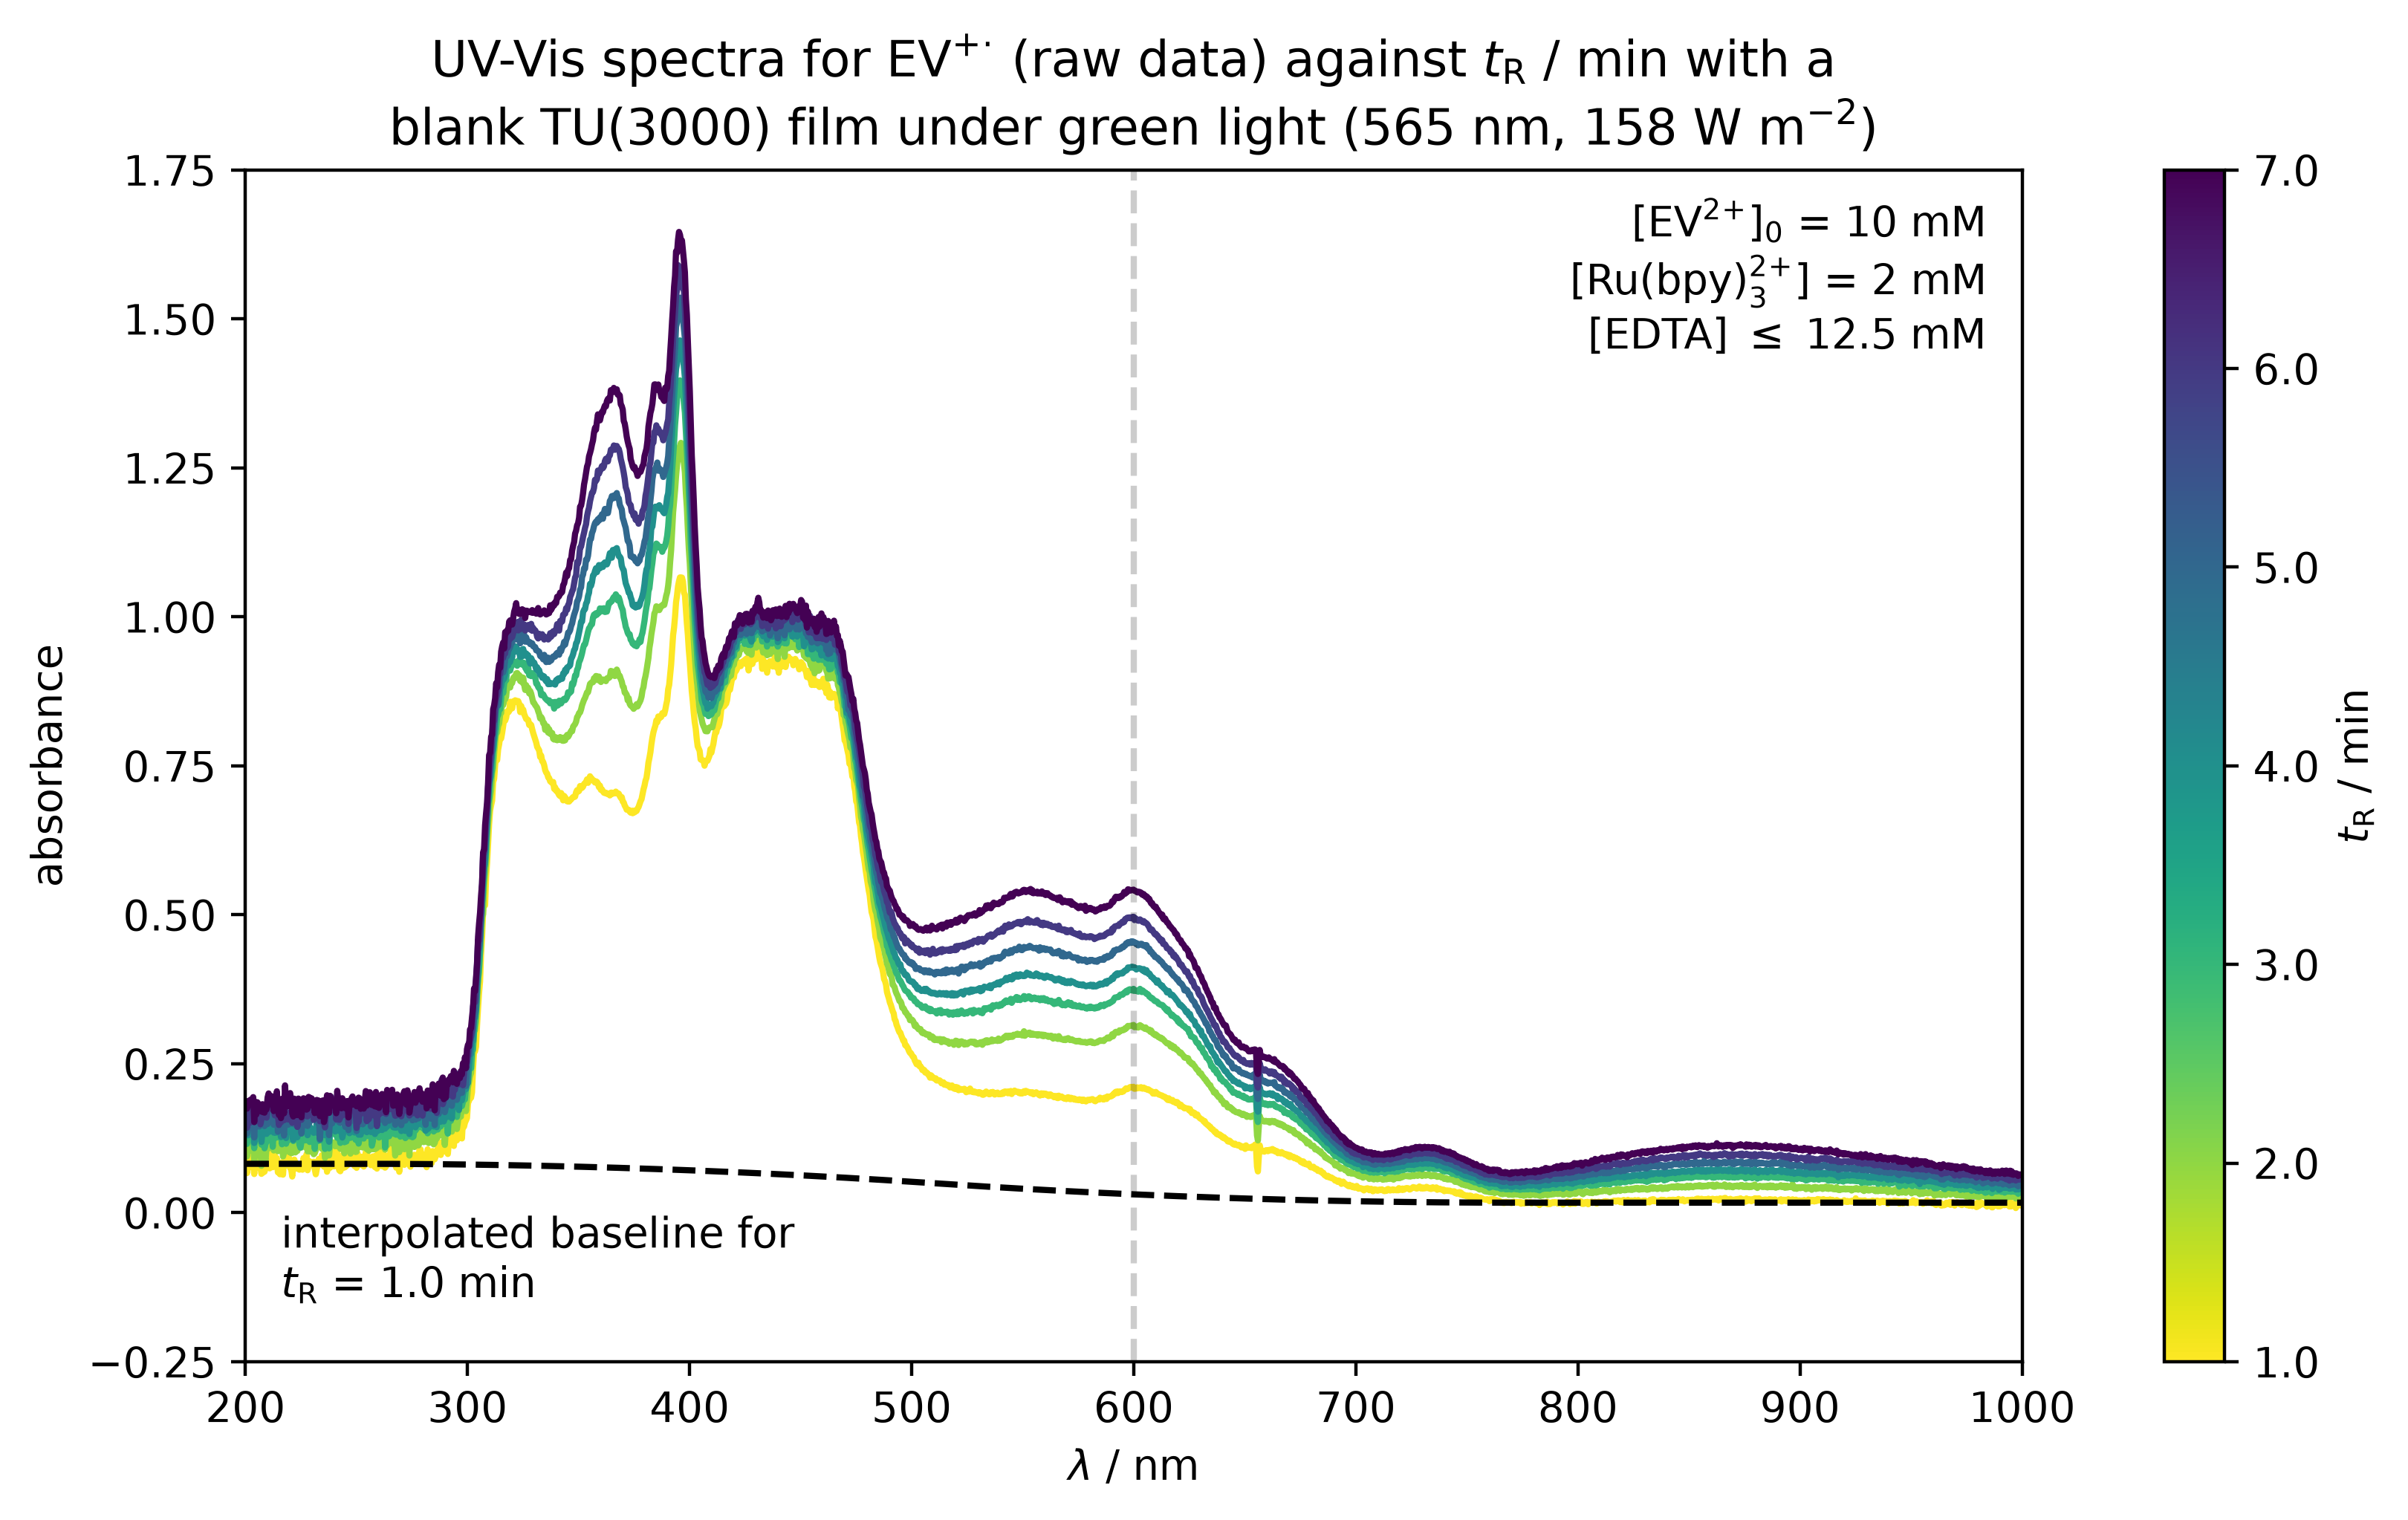

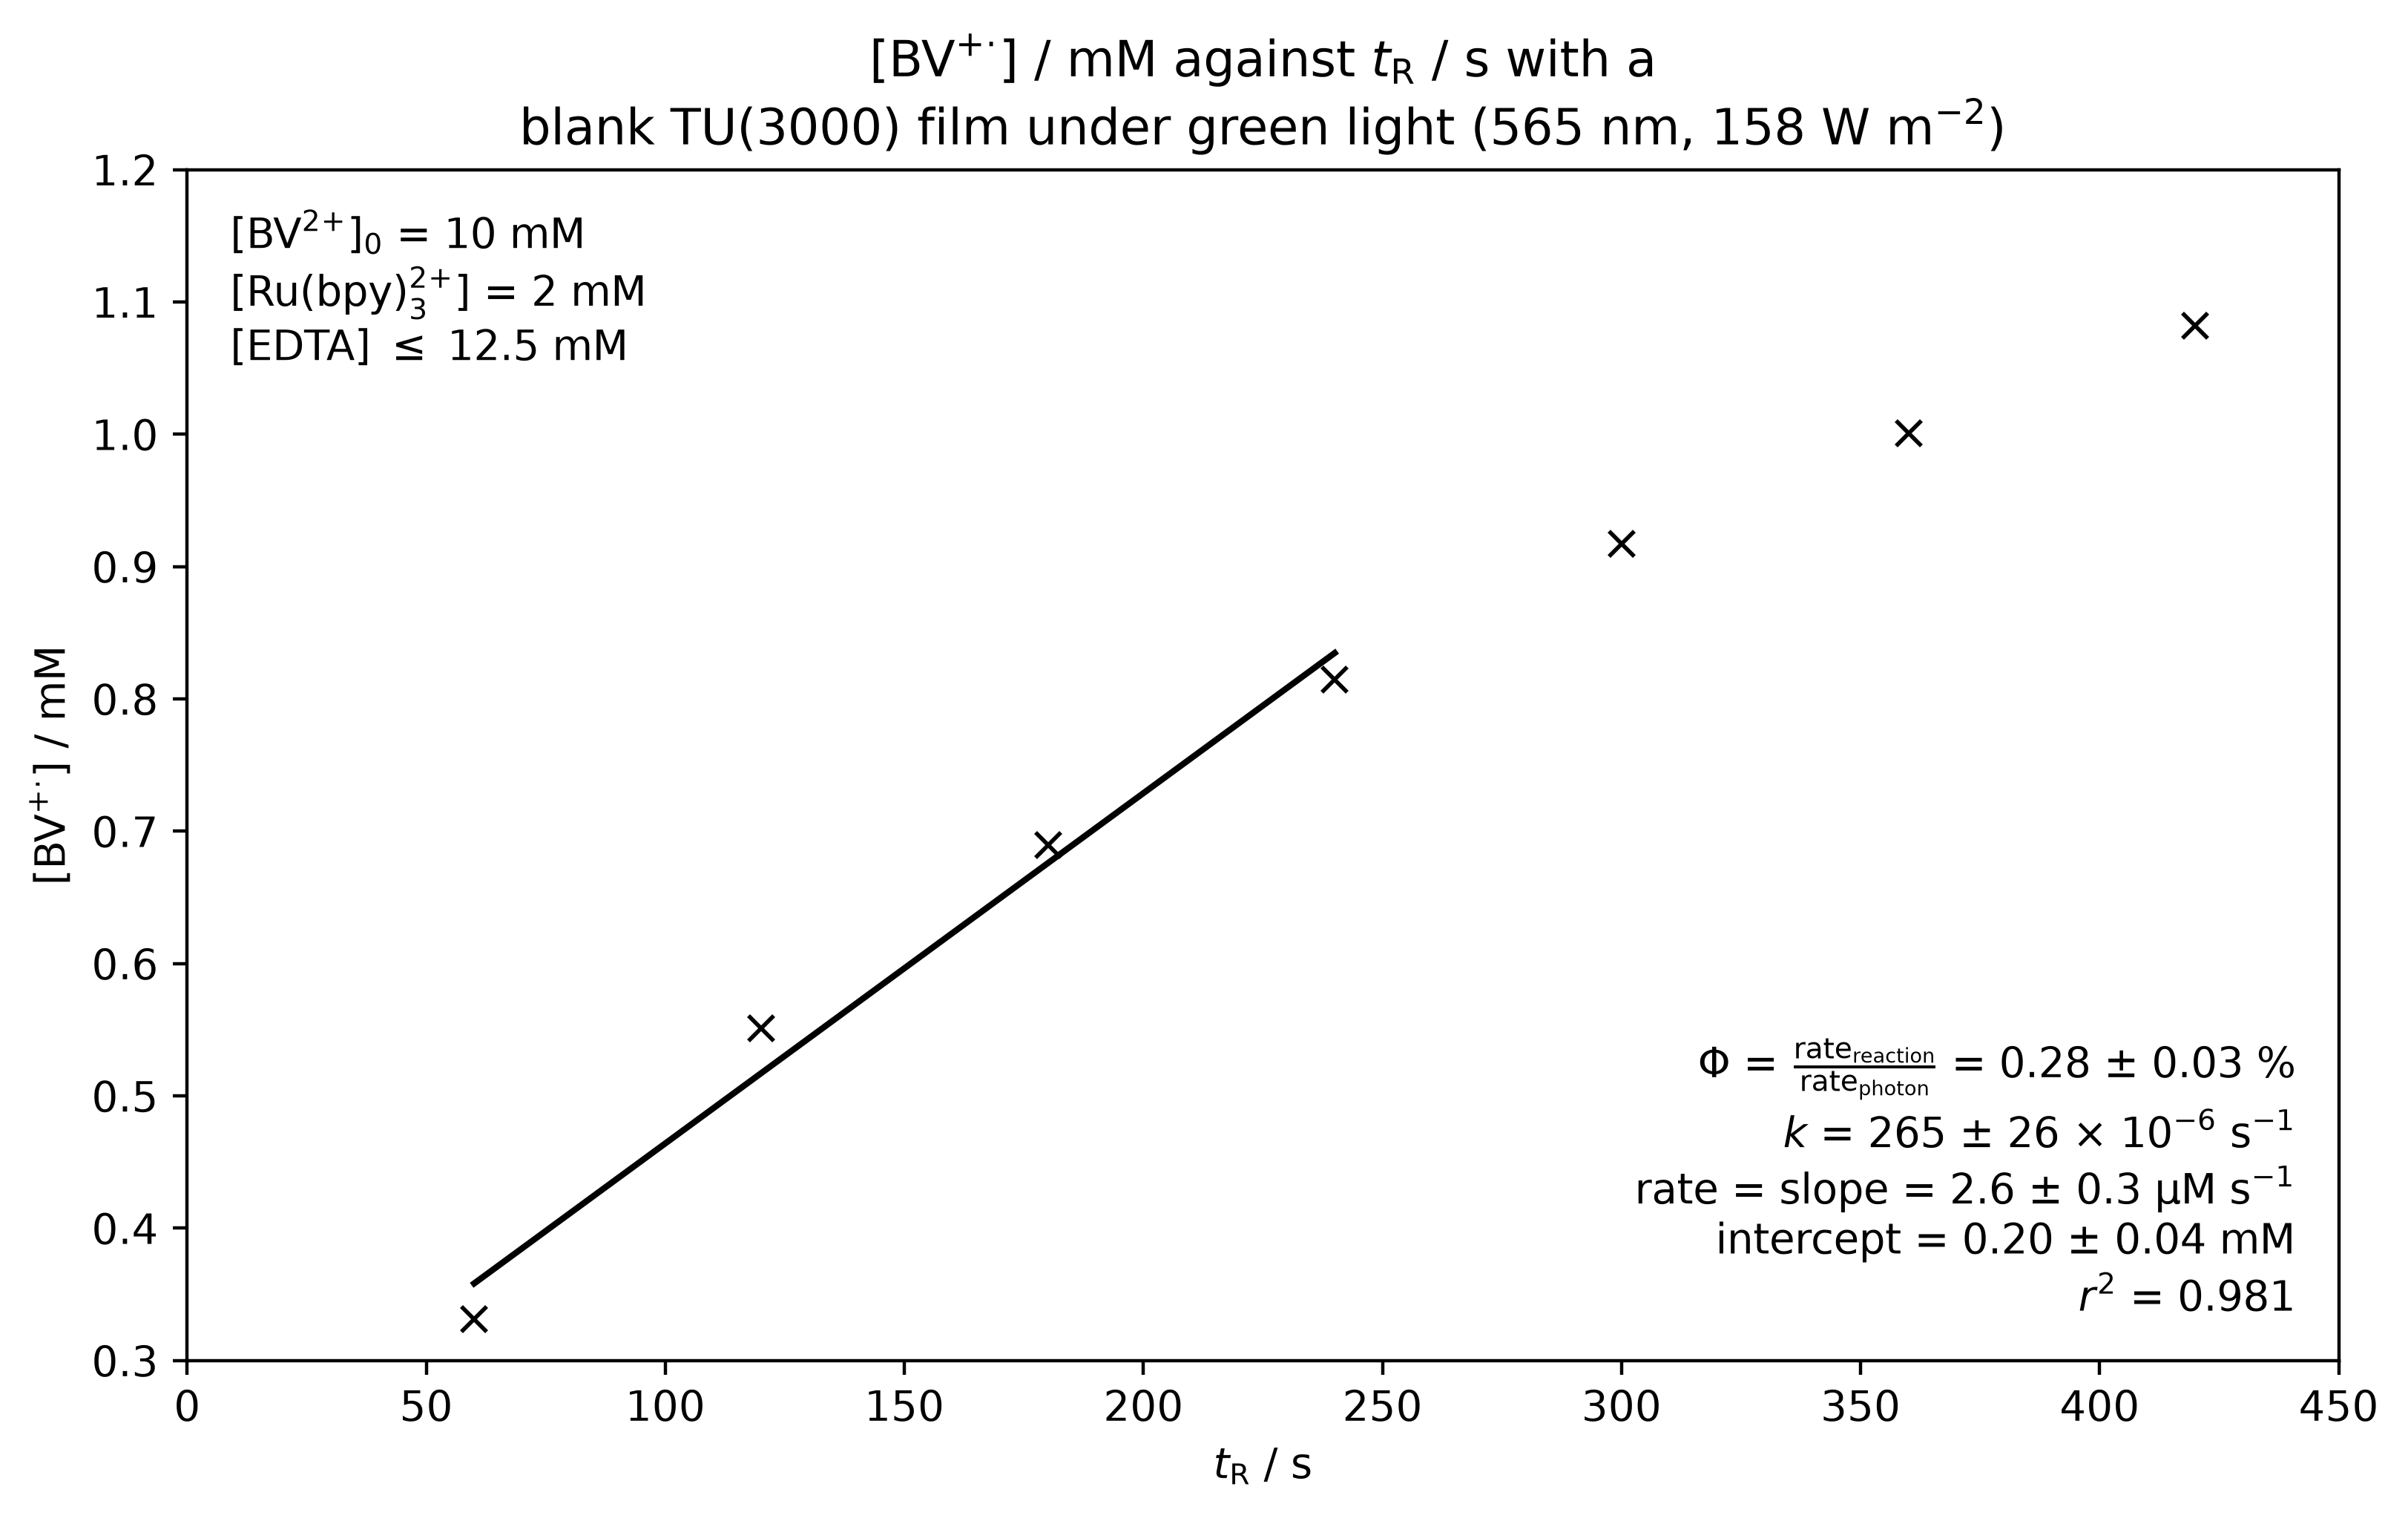

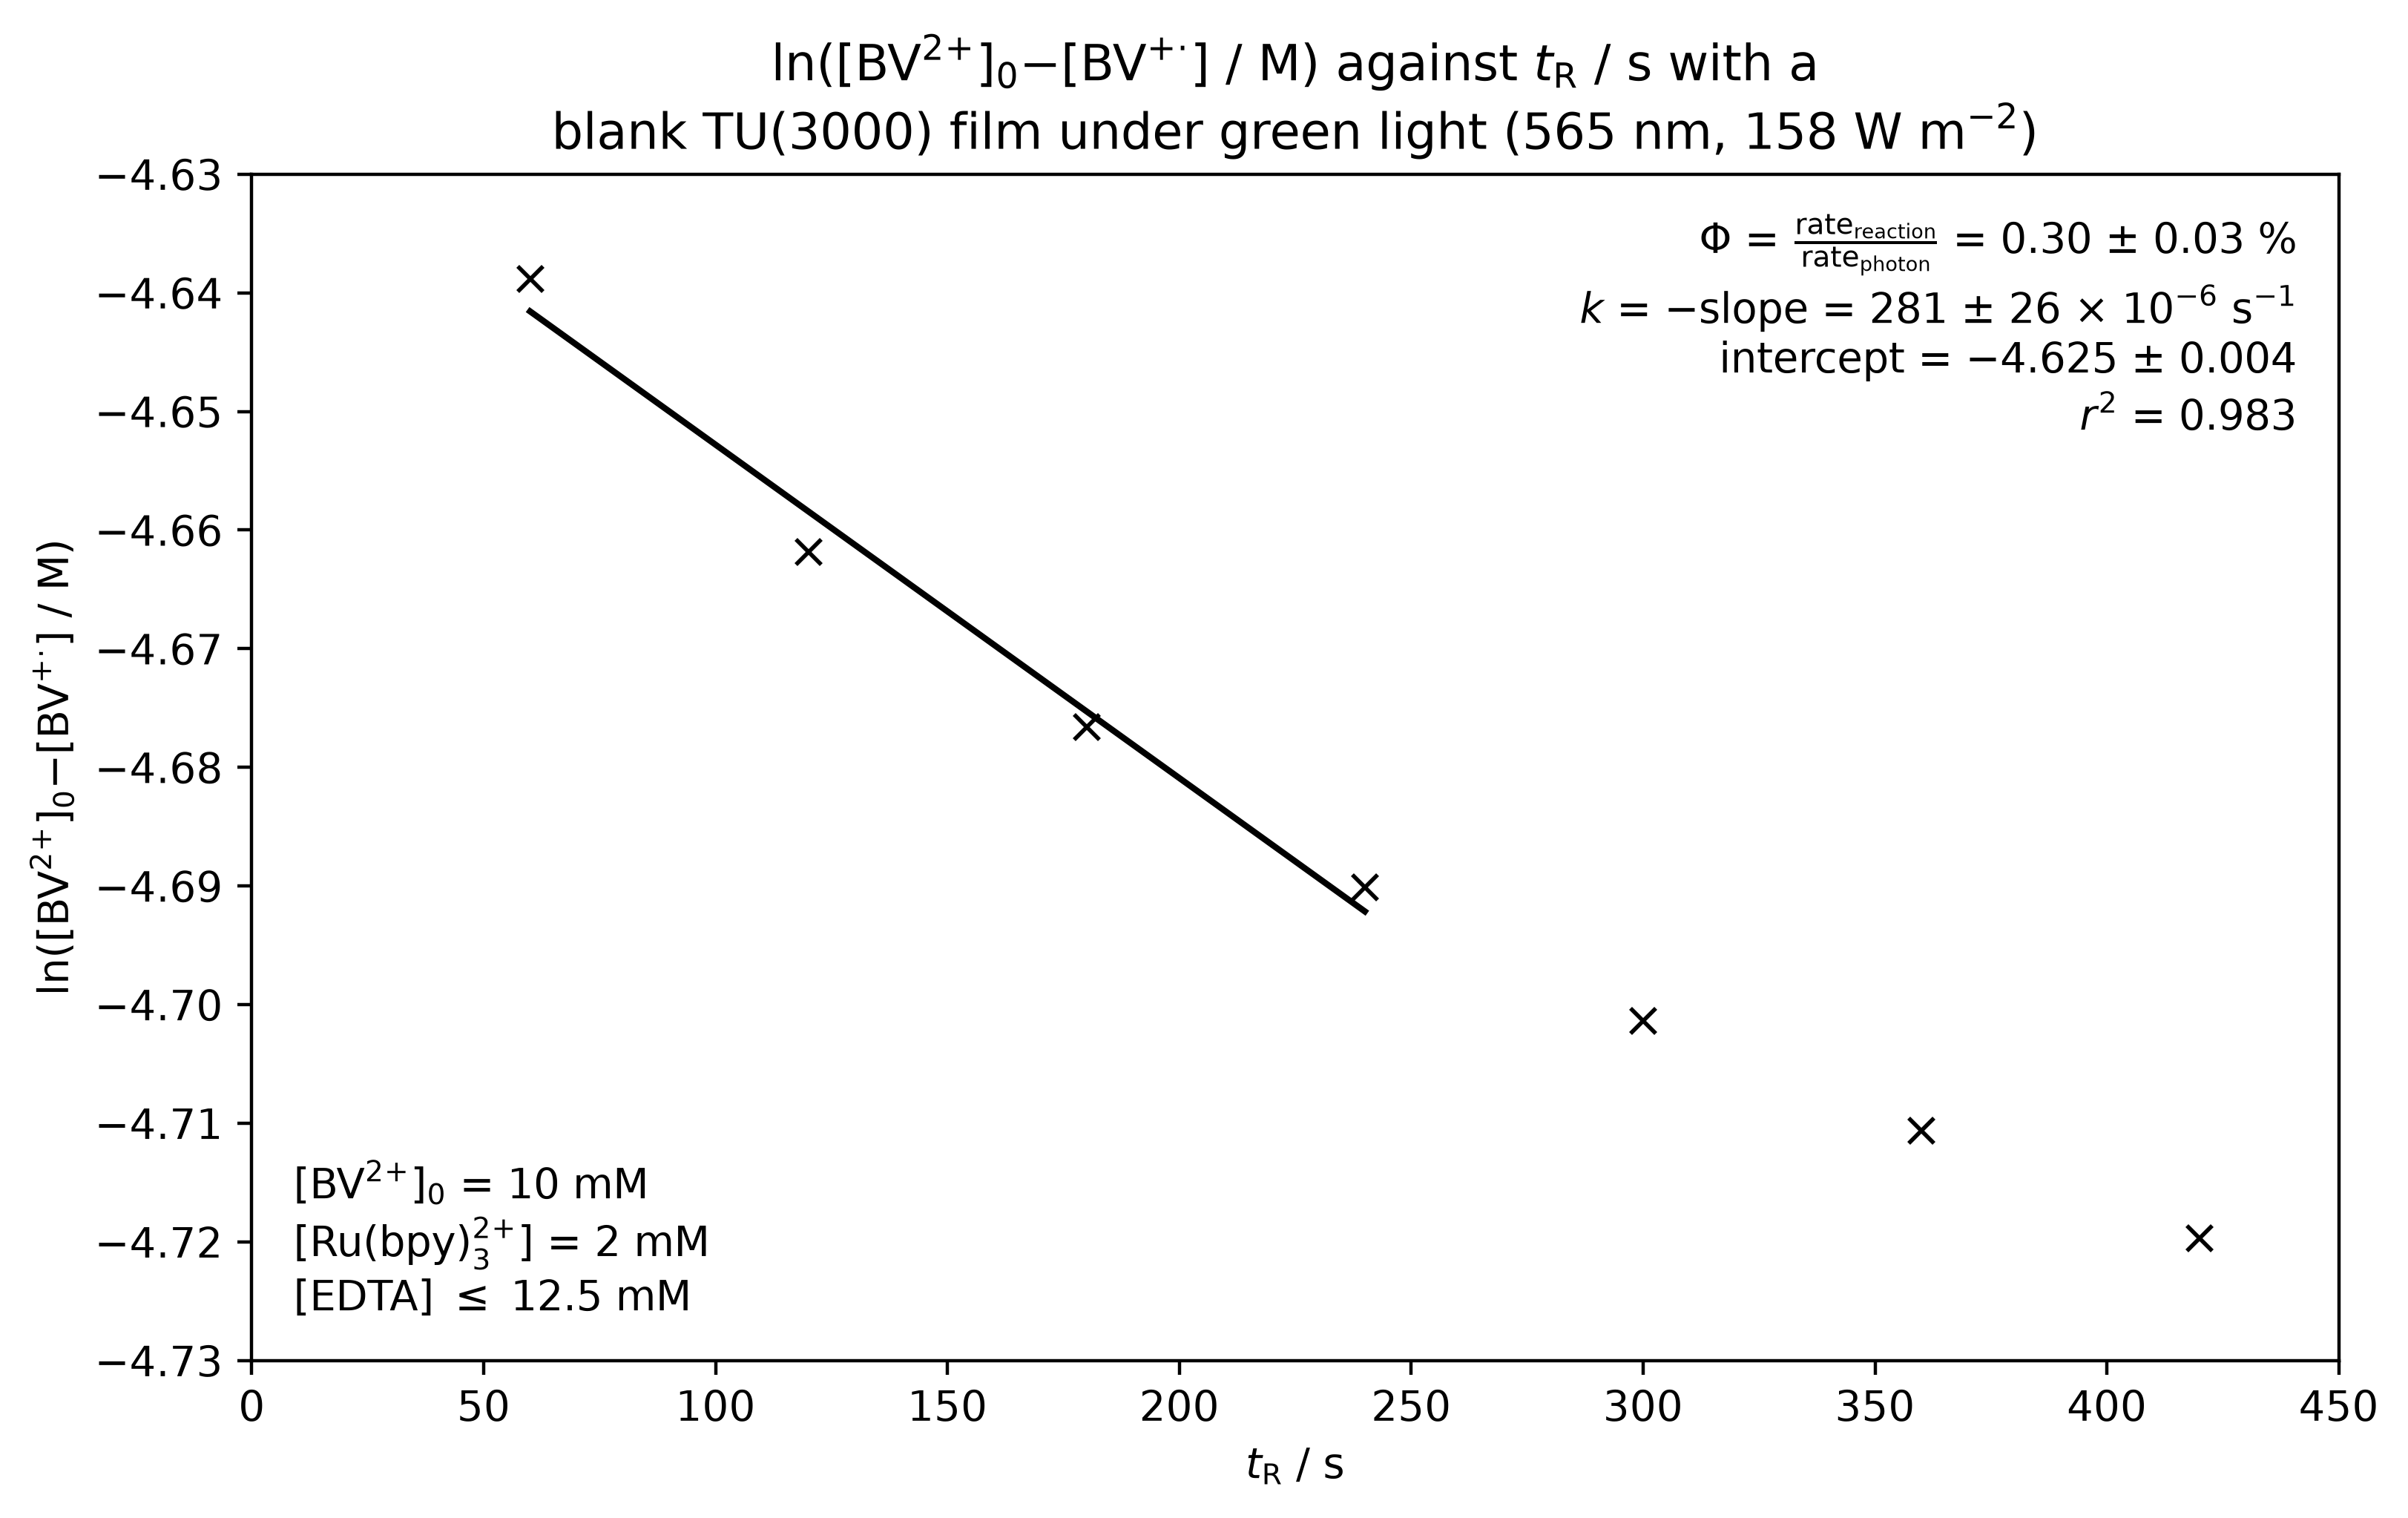

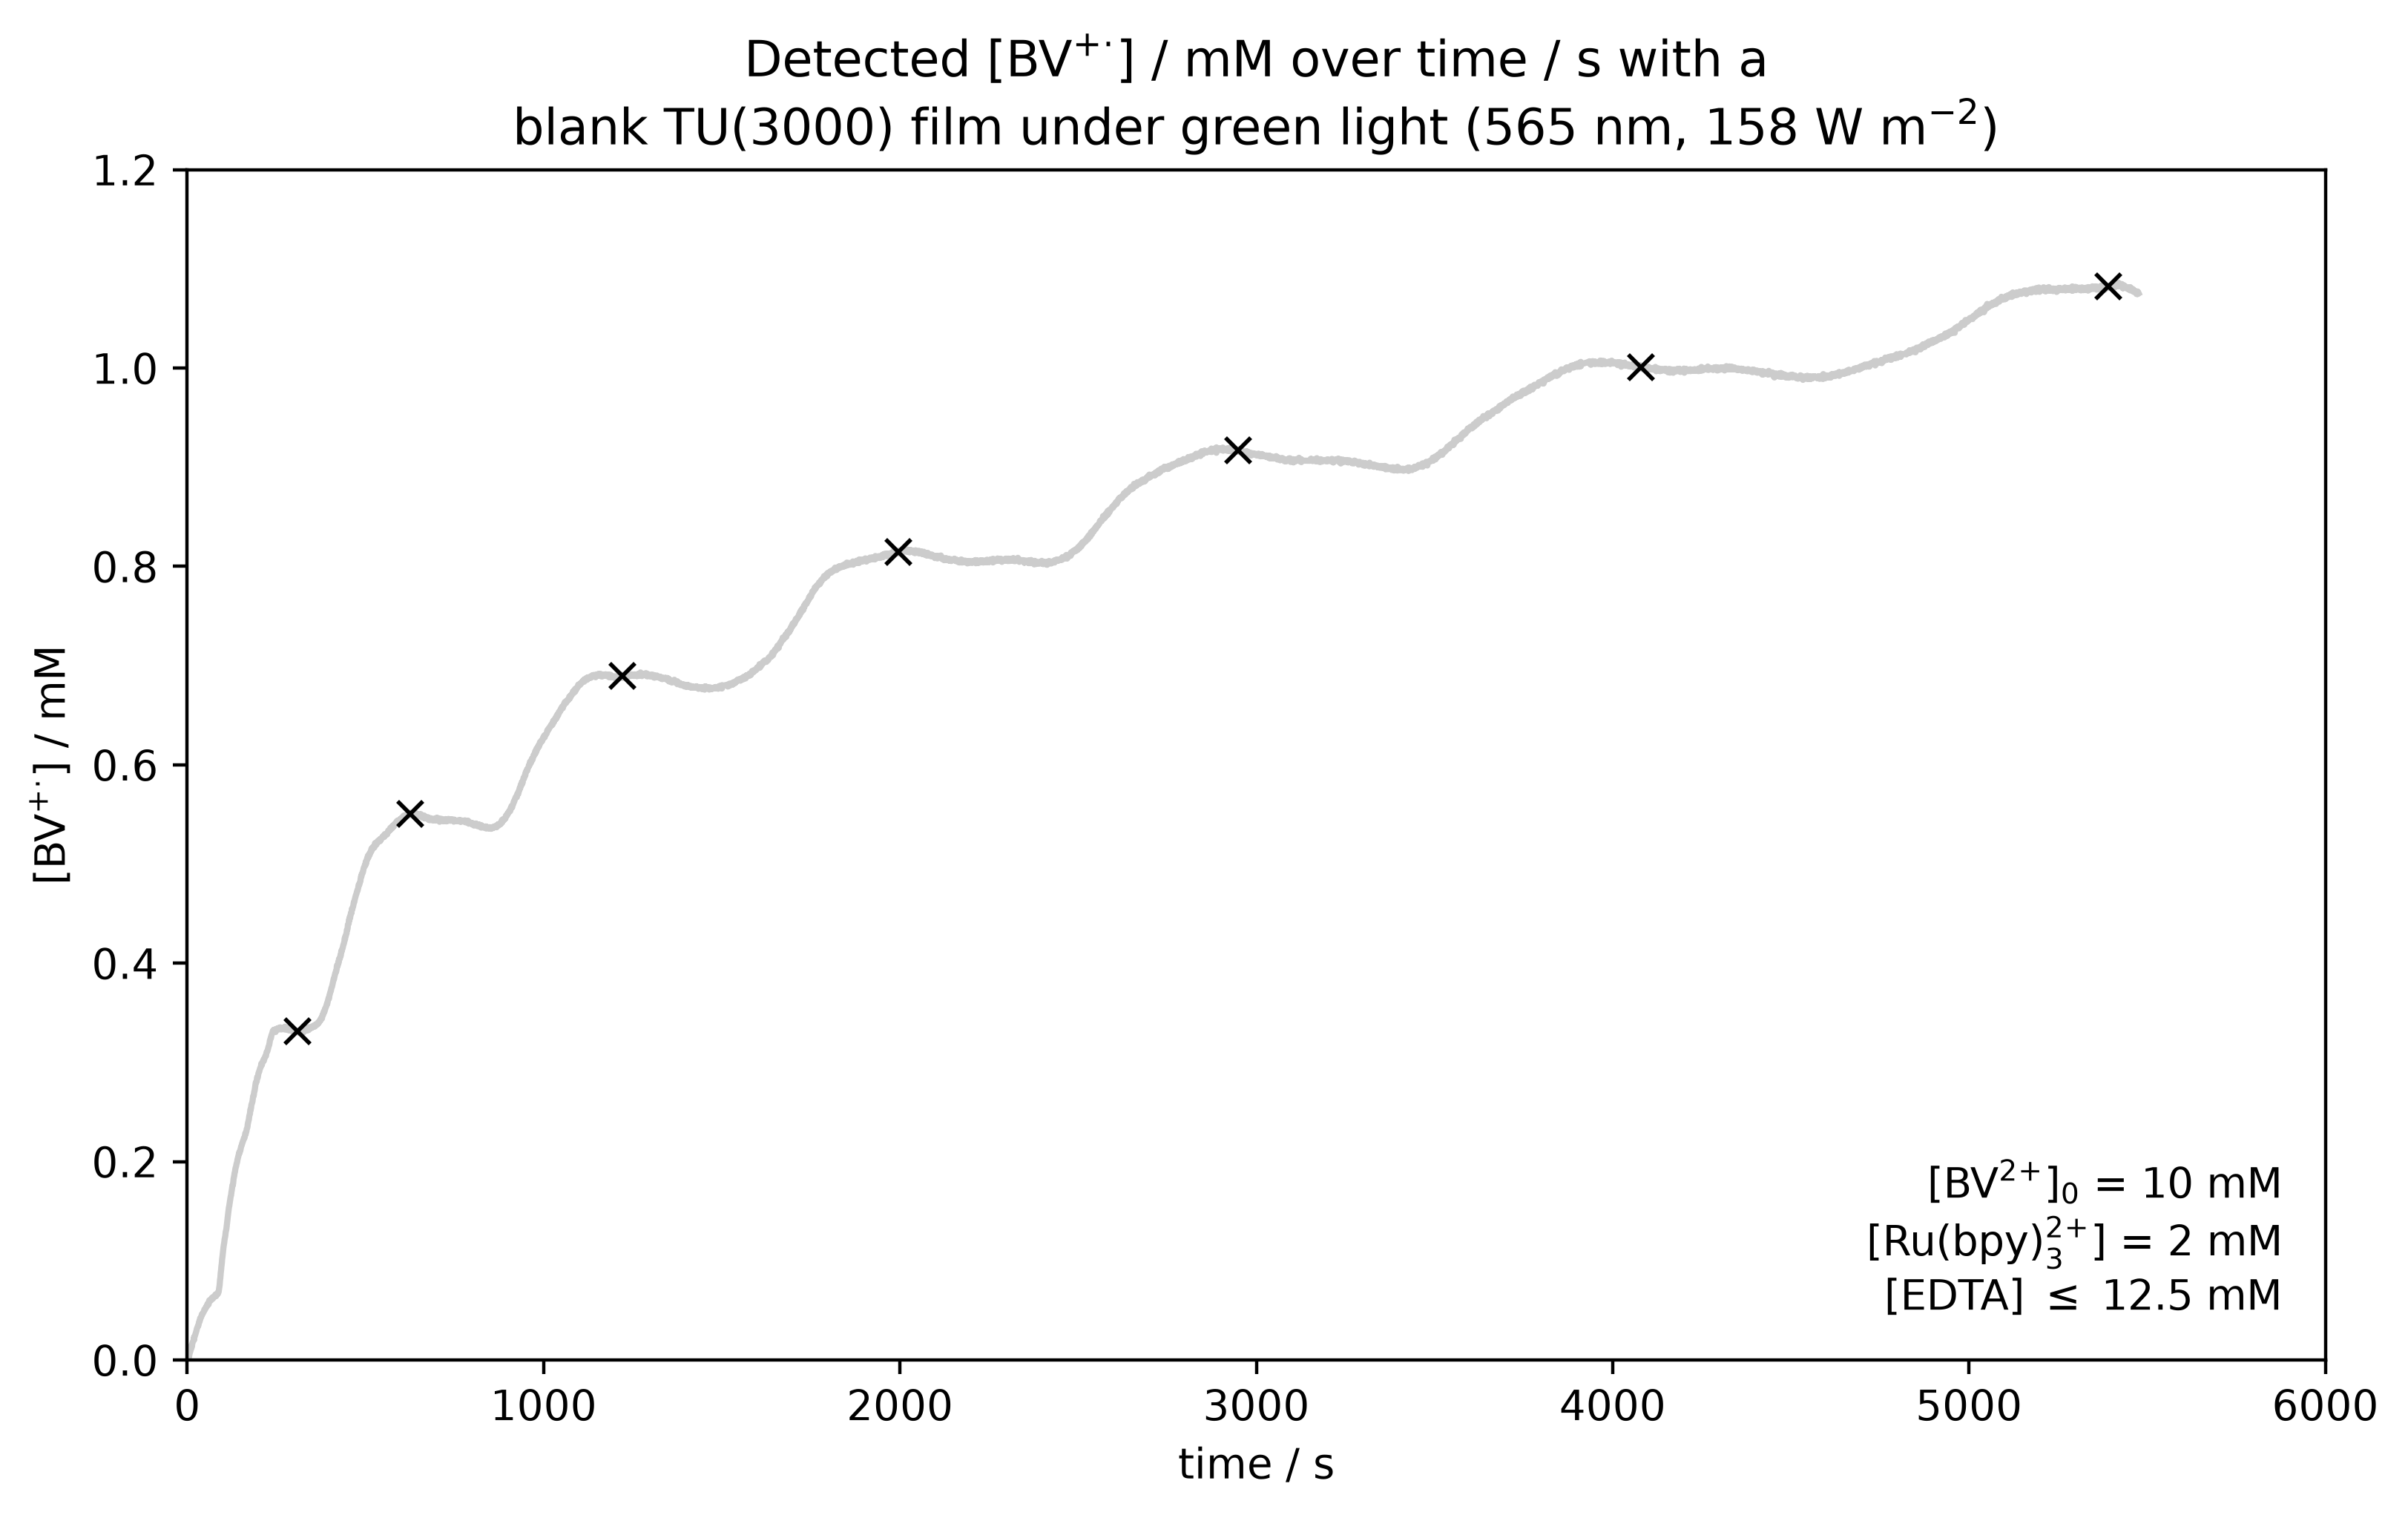

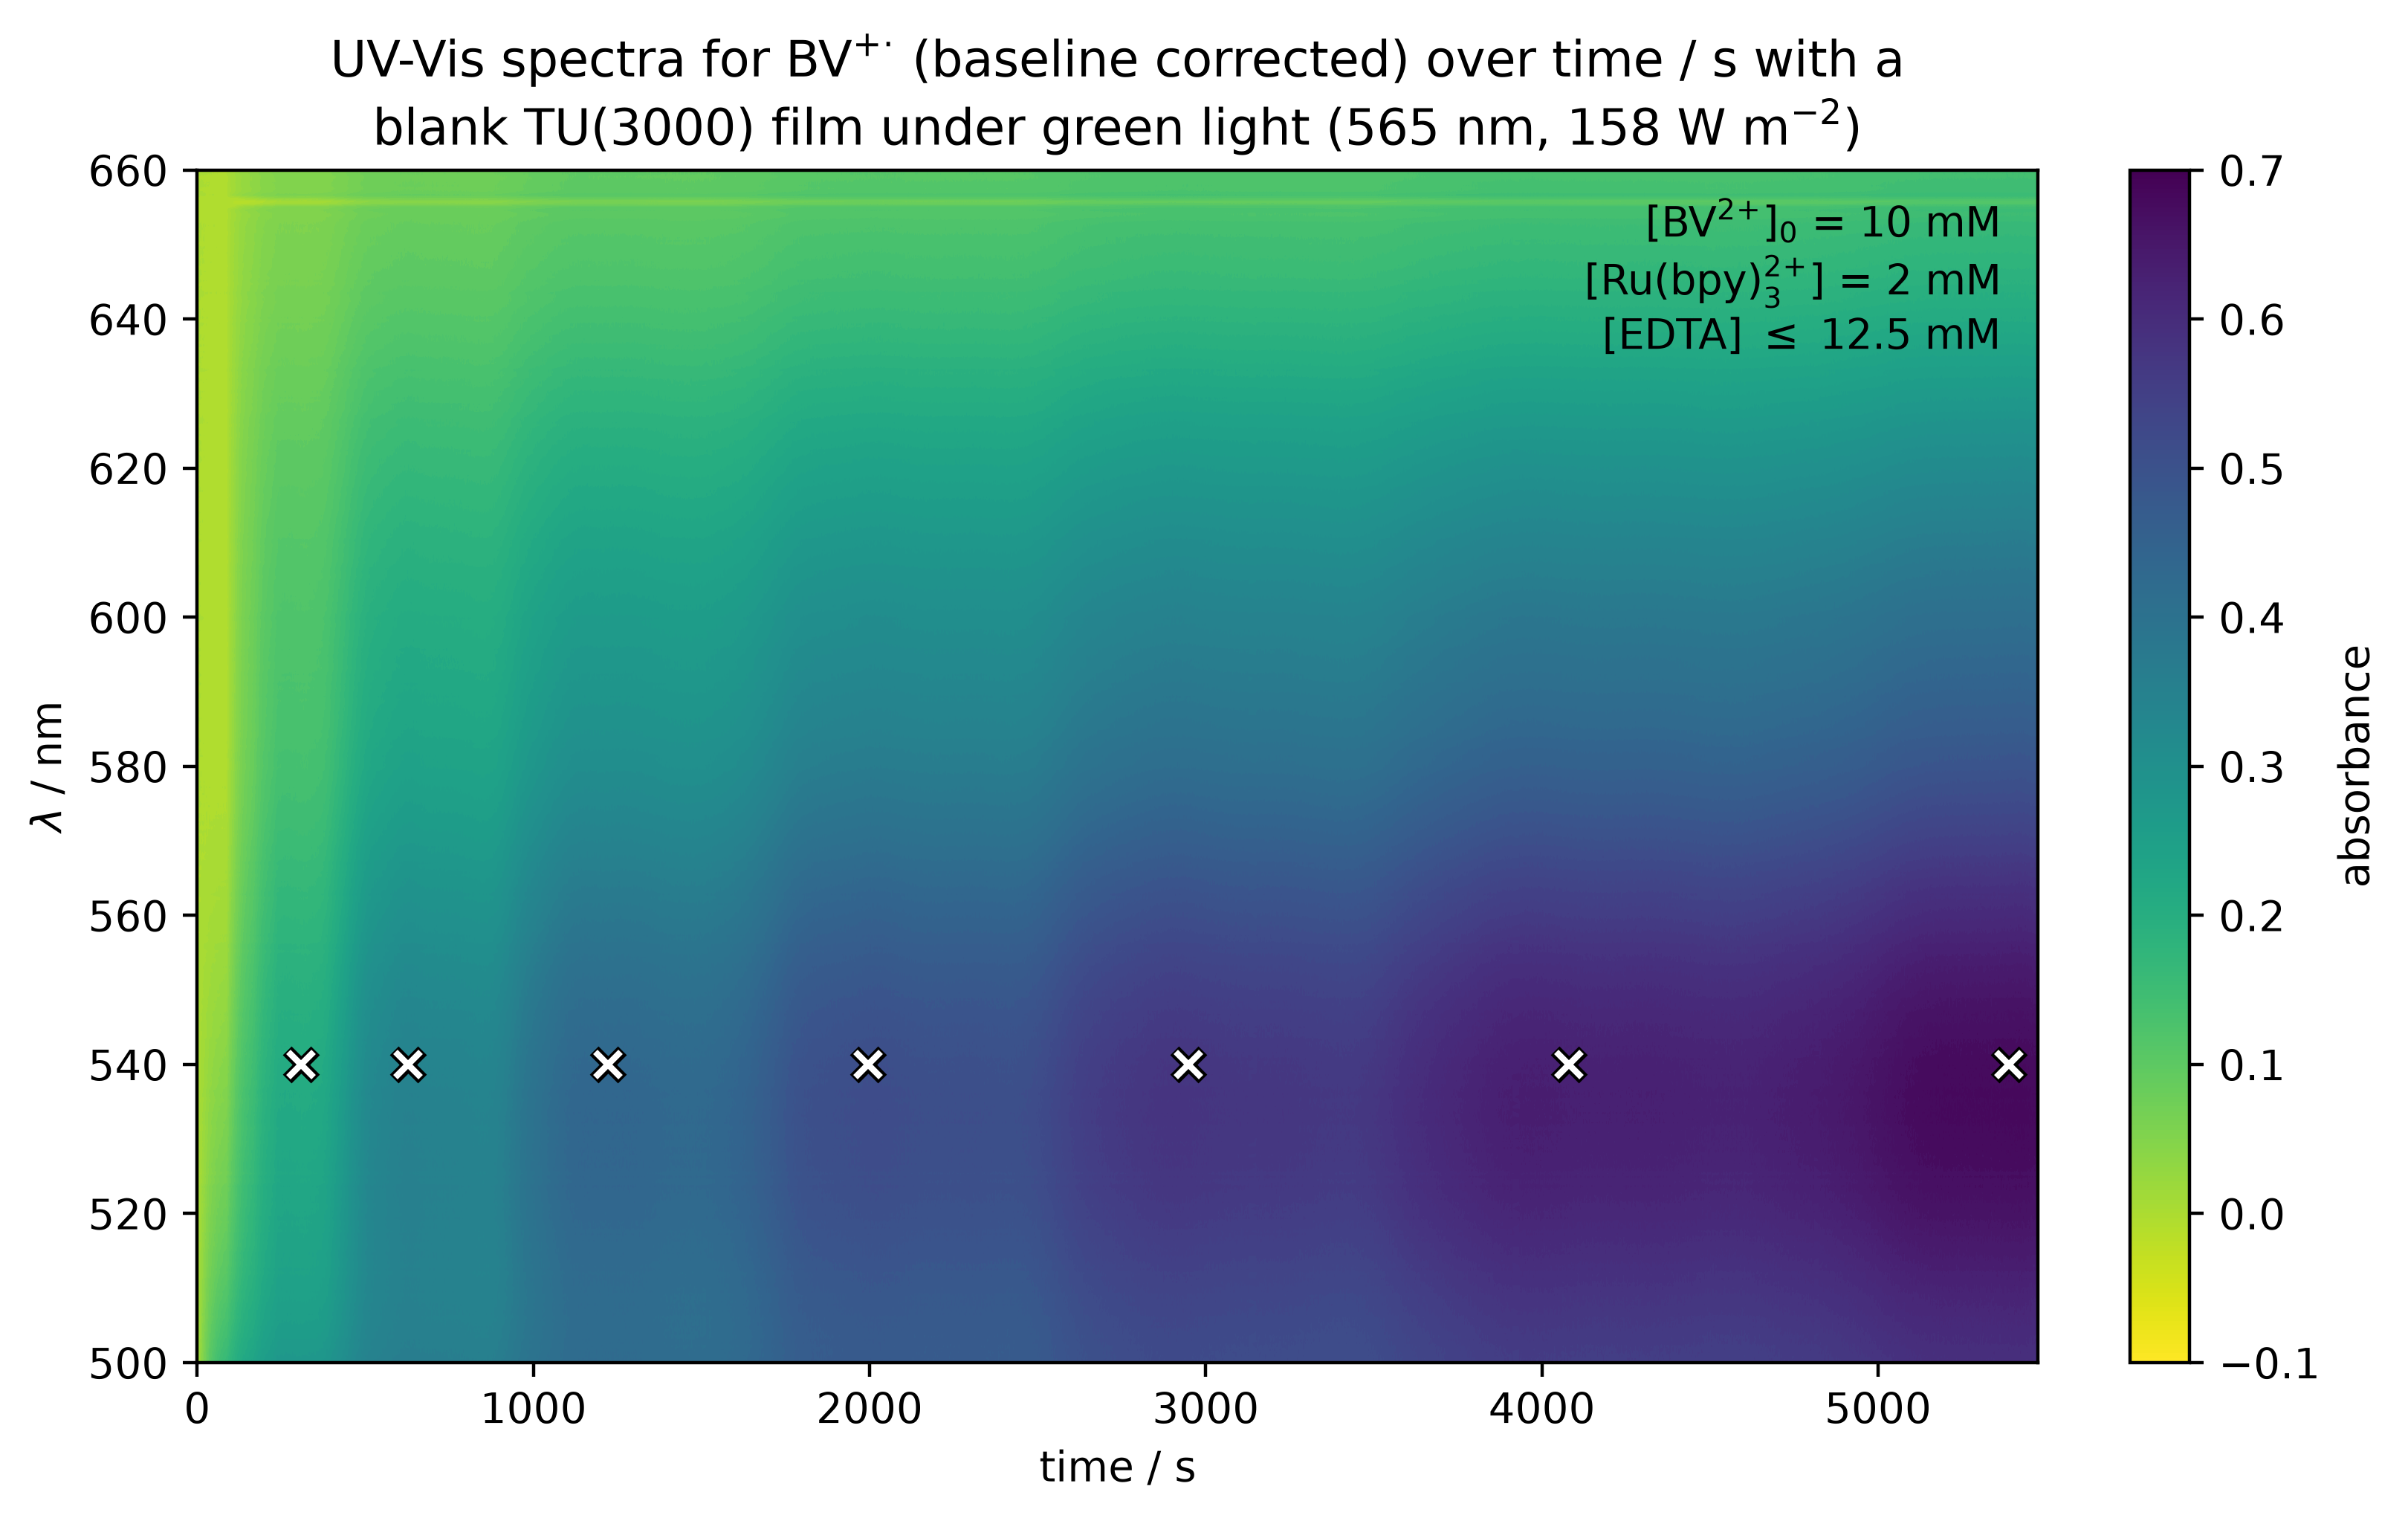

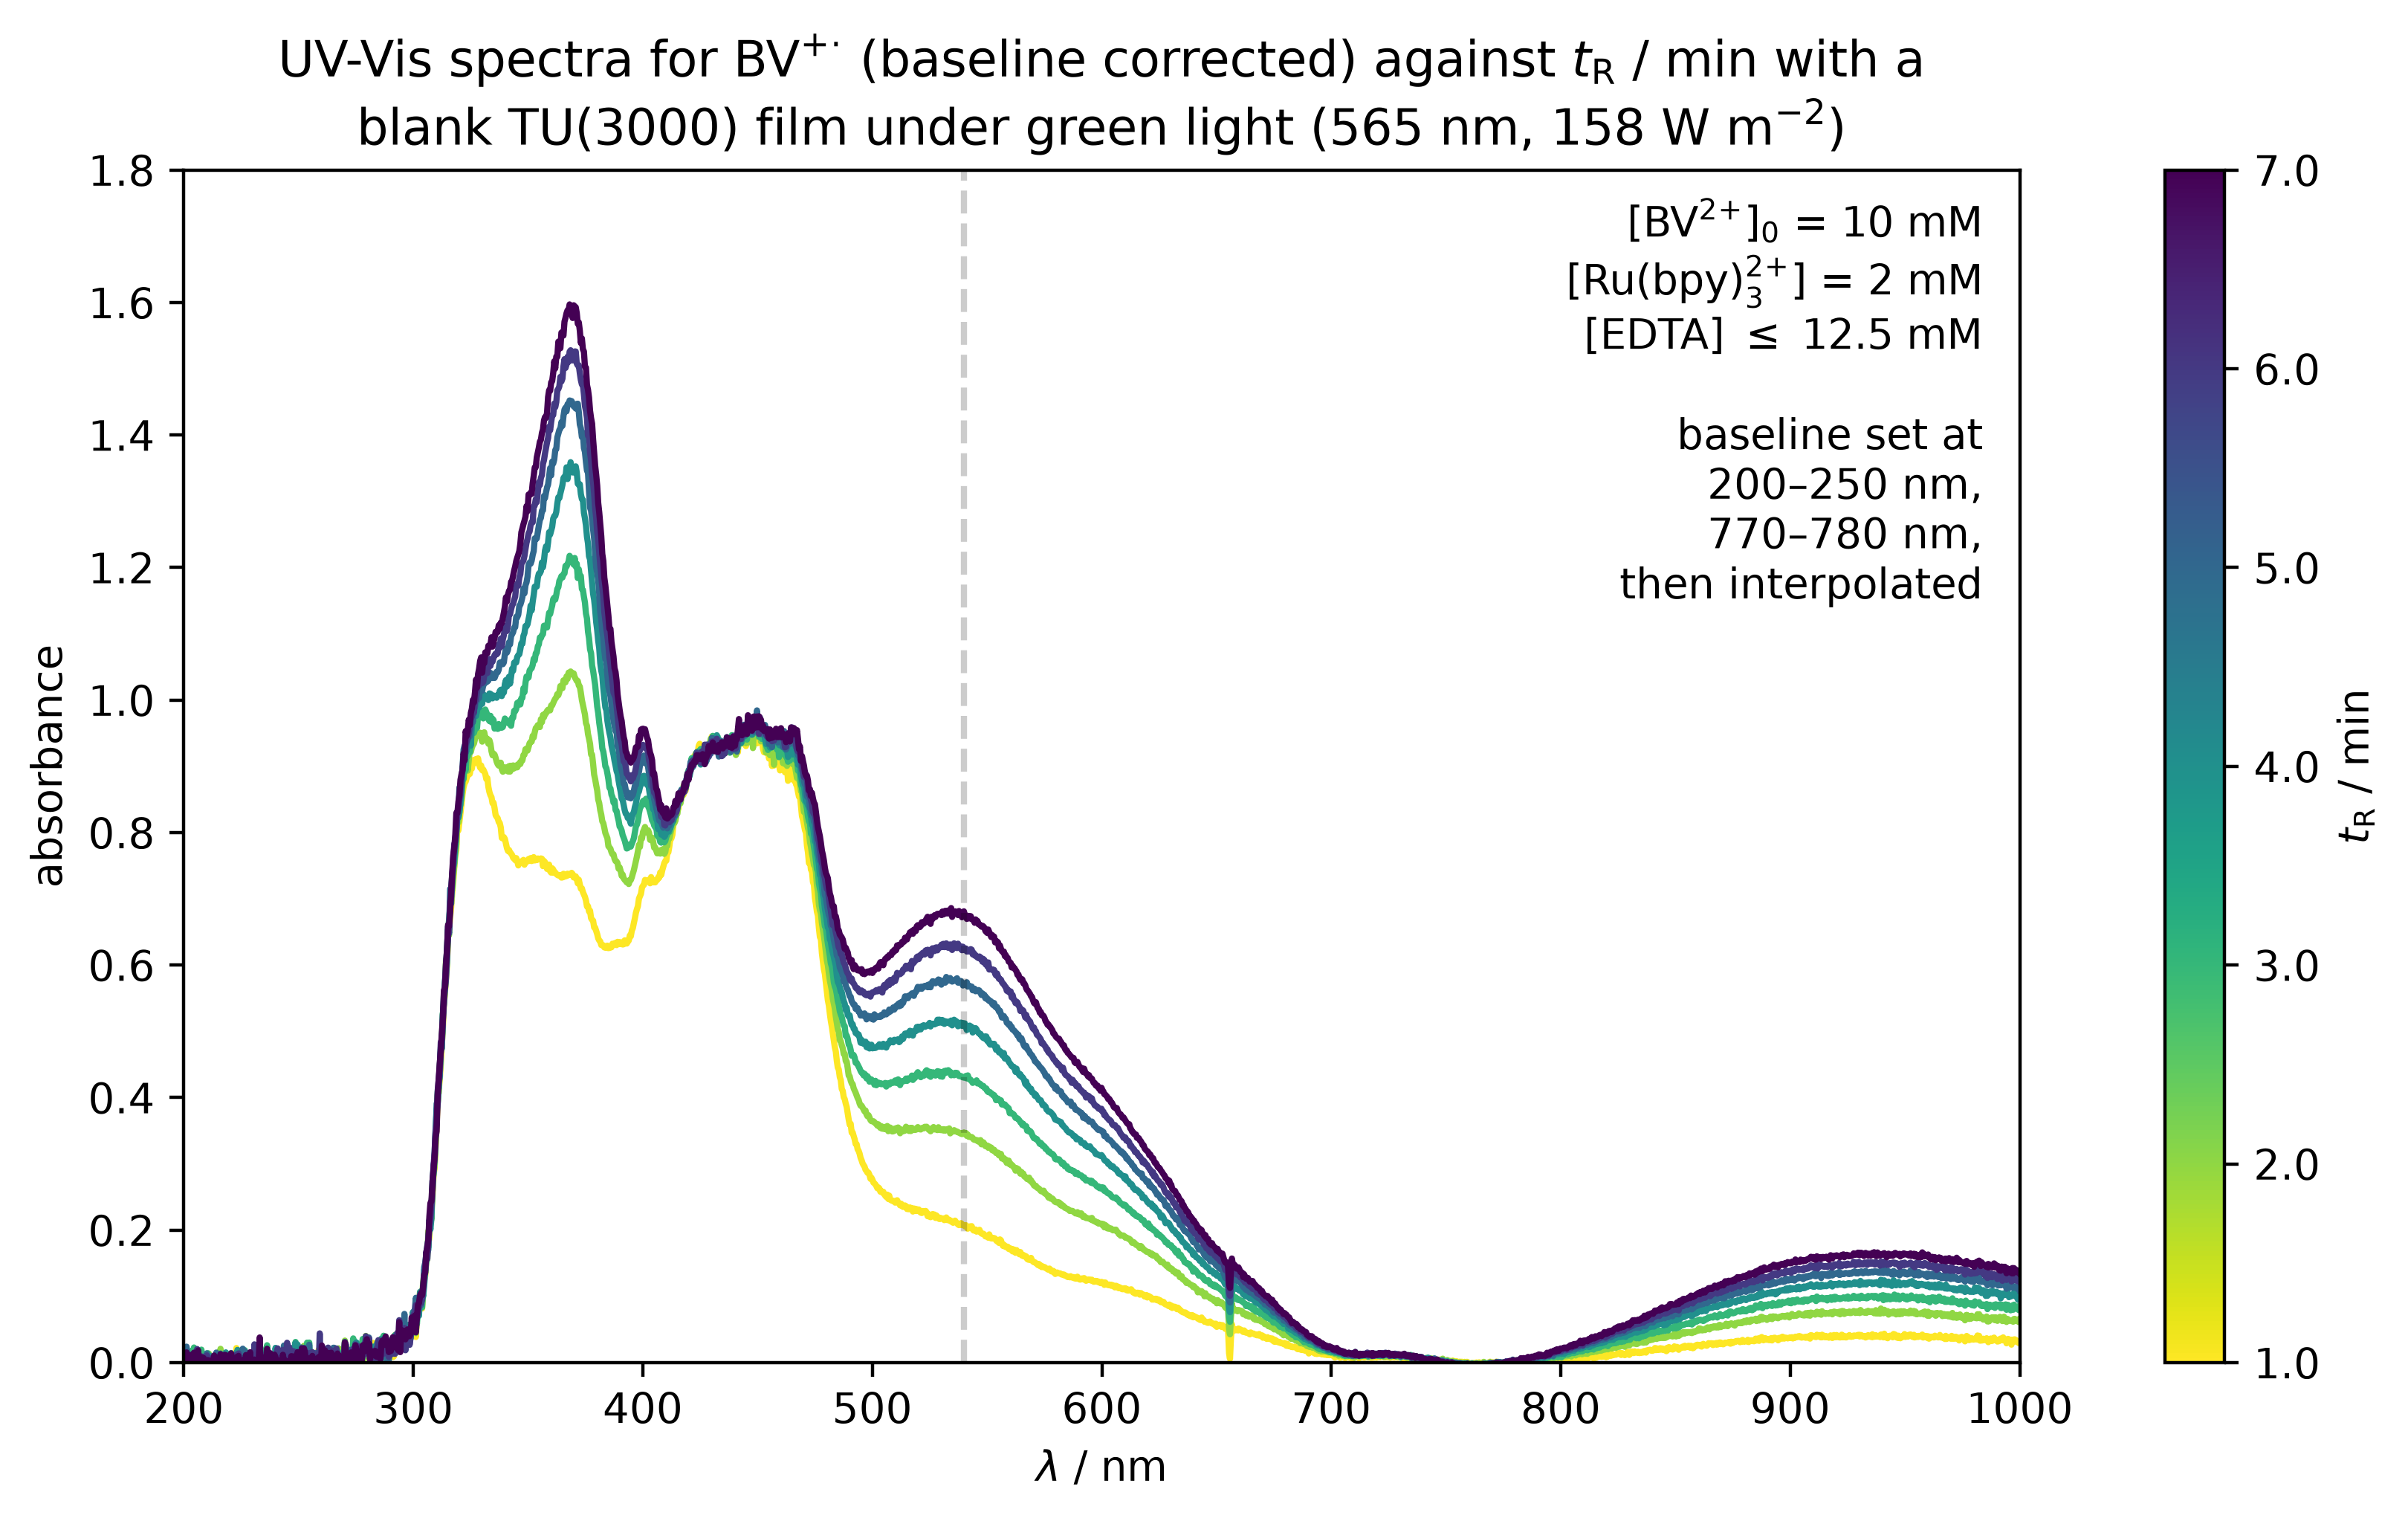

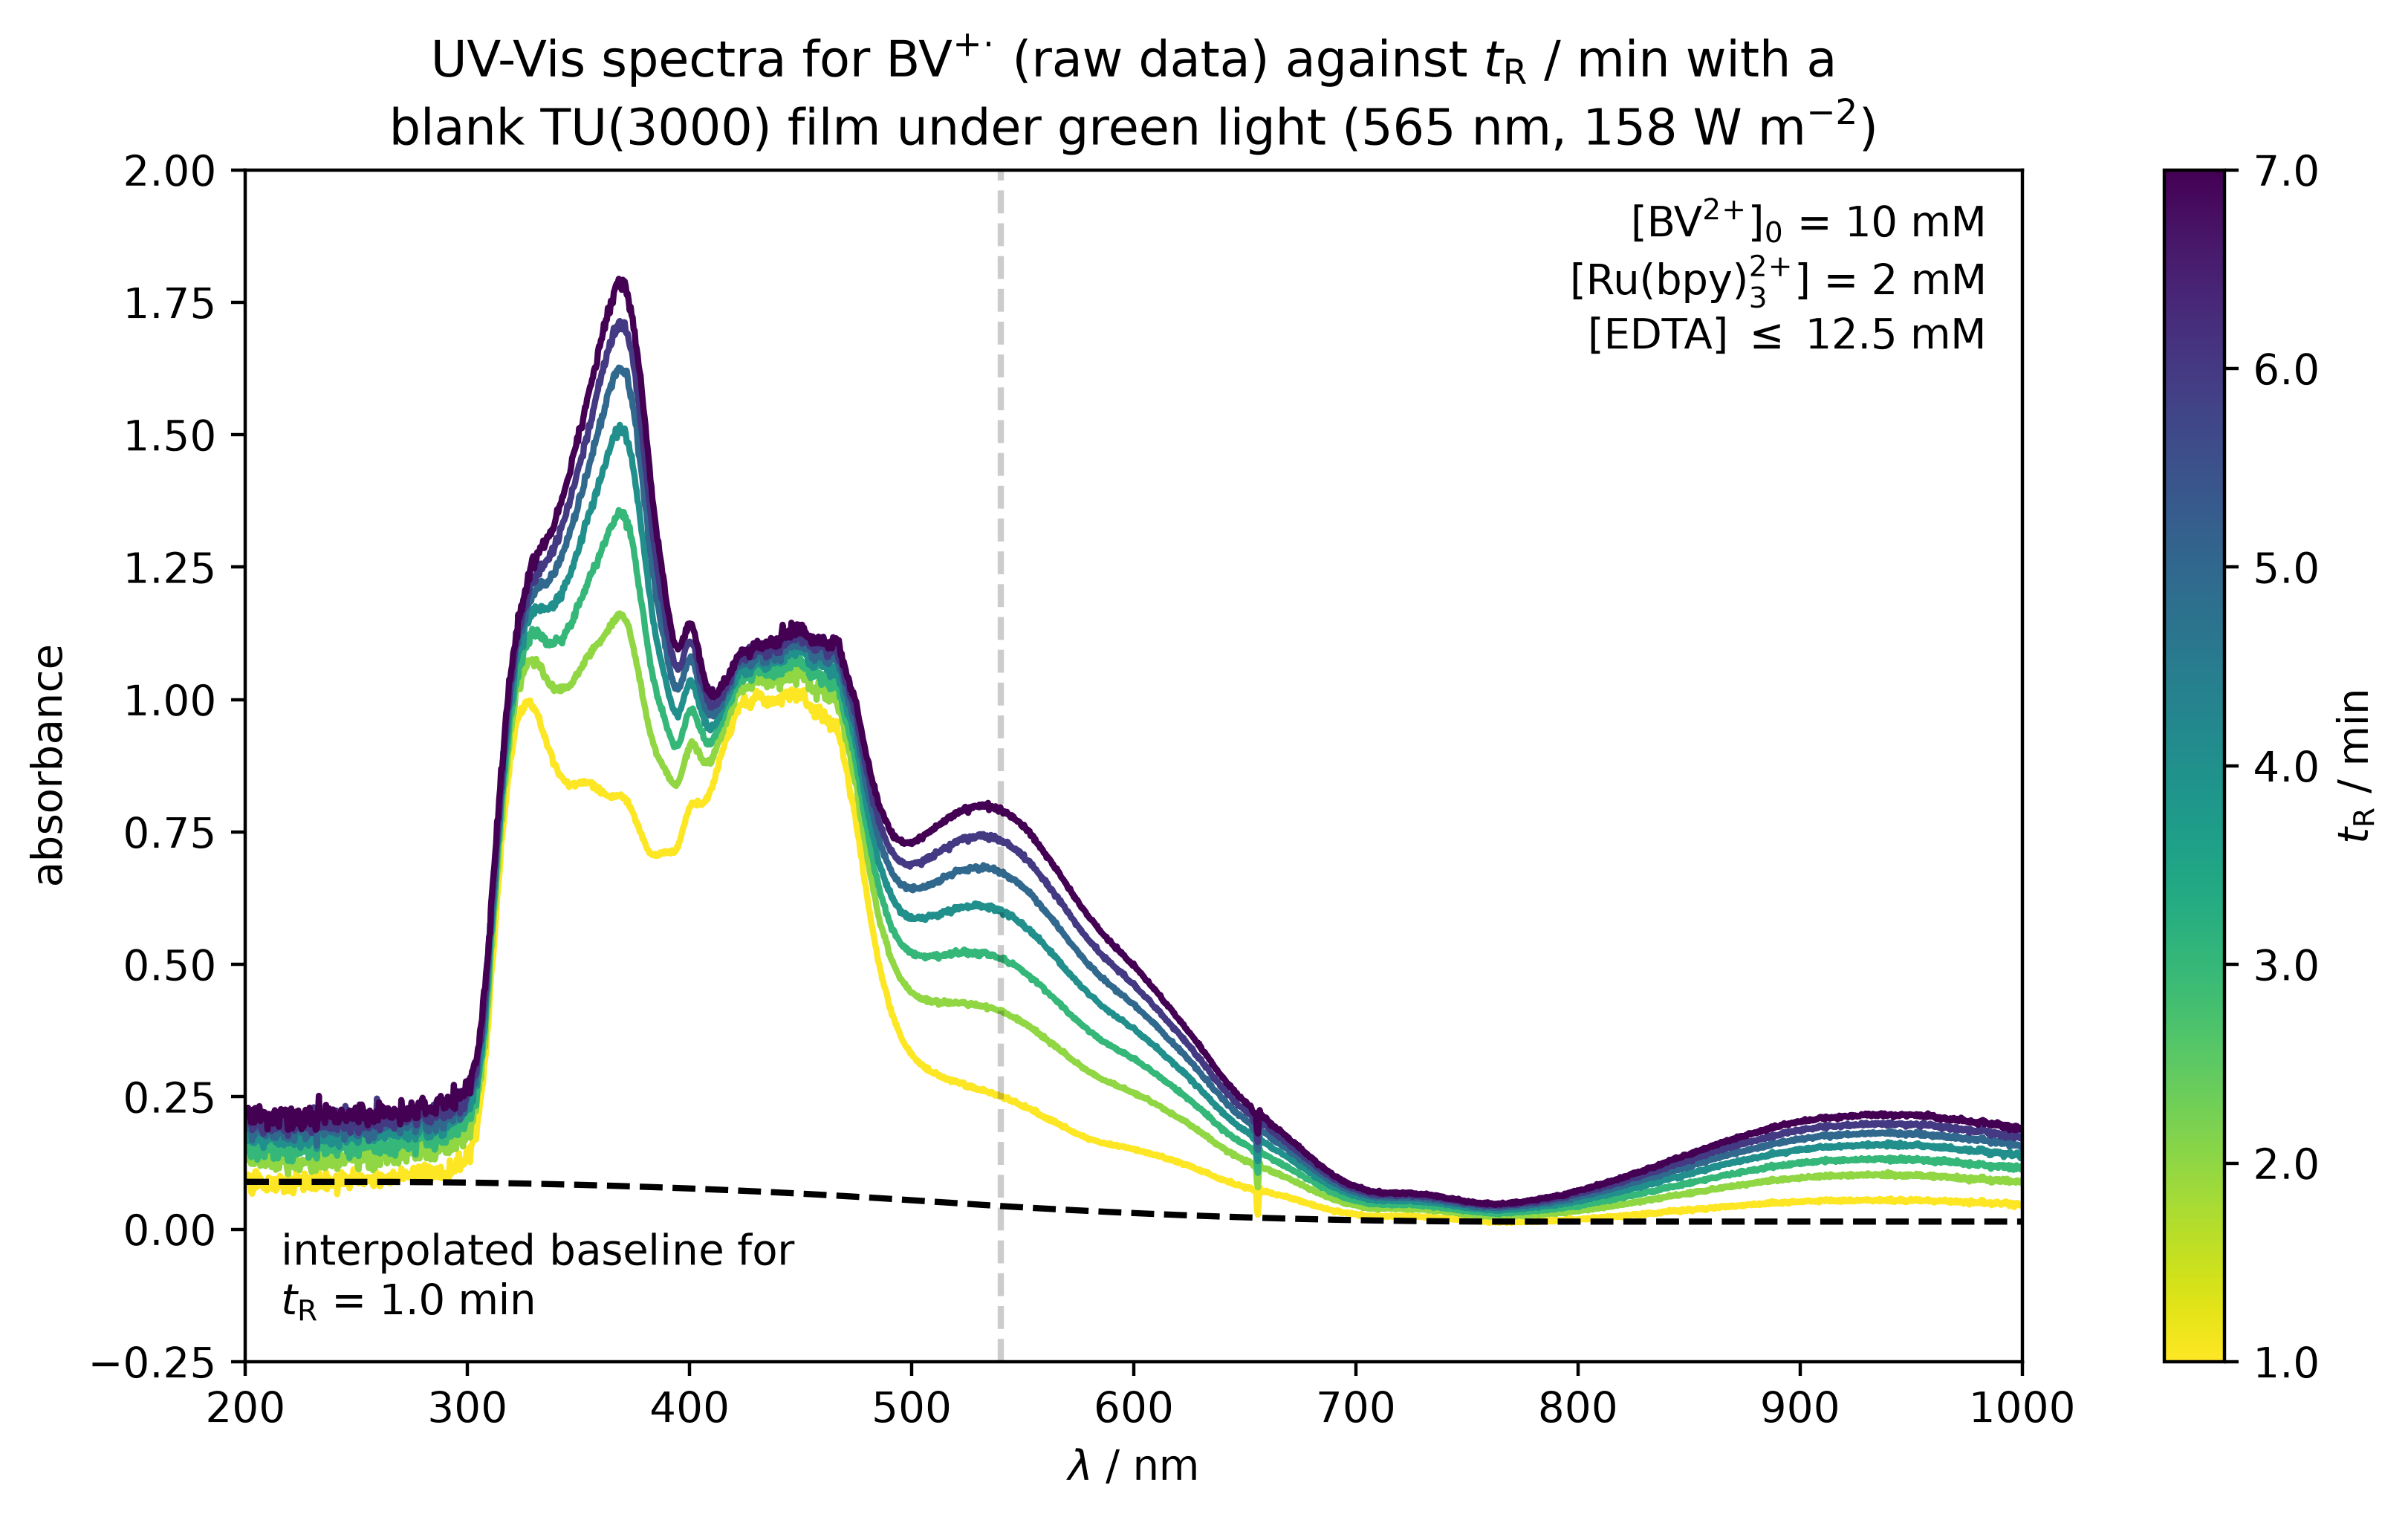

In [ ]:
from lsmr_photocatalysis import ContinuousFlow, FLOW_PARAMS, X
import numpy as np

"""
Continuous flow with reaction/LED/film and UV-Vis at opposite ends of a single 250 ul reactor chamber.
Flow rate changes according to flow scheme at different time points to change residence time tR.
Green 565 nm irradiation at 11.2 mW.

V([Ru(bpy)3]2+, 12 mM, pH 7 buffer) = 500 ul (2 mM)
V(XV2+, 30 mM, pH 7 buffer) = 1000 ul (10 mM)
V(EDTA, <25 mM saturated, pH 7 buffer) = 1500 ul (<12.5 mM)
"""

tRs = np.arange(60, 7*60+1, 60) # residence times/s for 1-7 min in 1 min intervals
points = ContinuousFlow.recpoints(tRs, *FLOW_PARAMS['250ul']) # time/s points to record absorbances
points[0] += 100 # add 100 s to the first record point

c0 = 10e-3 # initial EV2+ concentration
details = f'{X['RU']} = 2 mM\n[EDTA] $\\leq$ 12.5 mM' # concentrations of other reagents

film = 'blank TU(3000)' # 30/01/2024
light = 'green'
wavelength = 565e-9 # m
power = 11.2e-3 # W

for x, start, r2 in [('EVrubpy', '11-57-00-000', 0.97), ('BVrubpy', '15-45-00-000', 0.98)]:
    data = f'260805_Rubpy_{x[0]}V_EDTA_TU(3000)_Blank_Green_Flow' # data folder name
    expt = ContinuousFlow(data, tRs, points, start, c0, details, x, film, light, wavelength, power)
    expt.concvstimeplot(r2threshold=r2)
    expt.concvstimeplot(ln=True, r2threshold=r2)
    expt.detectorconcplot()
    expt.detectorspectrumplot()
    expt.spectrumvstimeplot()